Author(s) : Laura Gómez Navarro, Daniel R. Tarry, ...

Objective: Describe xxx

Created on: May 2023


In [2]:
import time

print('Last update:', time.ctime(time.time()))

Last update: Wed Apr  3 12:54:15 2024


<a id="0"></a> <br>
# Table of Contents  
1. [Loading the data](#1)     
    1. [Drifters](#1.1.) 
        1. [SVP-B](#1.1.1.) 
        2. [CARTHE](#1.1.2.) 
        3. [HEREON](#1.1.3.) 
    2. [Daily satellite field (Chl)](#1.2.) 
    3. [SWOT passes](#1.3.) 
2. [Plotting all trajectories](#2)
    1. [SVP-B drifters](#2.1.)
        1. [Full trajectories (zoom)](#2.1.1.)
        2. [Full trajectories (full map extent)](#2.1.2.)
        3. [Full trajectories (traj. extent)](#2.1.3.)
    2. [CARTHE](#2.2.)
        1. [Full trajectories (regional zoom)](#2.2.1.)
        2. [Full trajectories (full map extent)](#2.2.2.)
        3. [Full trajectories (traj. extent)](#2.2.3.)
        4. [Only trajectory on day 15/05/23 (+/- 1 day)](#2.2.4.)
        5. [Full trajectories (regional zoom) + Highlight of trajectory on day 15/05/23 (+/- 1 day)](#2.2.5.)
    3. [HEREON](#2.3.)
        1. [Full trajectories (regional zoom)](#2.3.1.)
        2. [Full trajectories (full map extent)](#2.3.2.)
        3. [Full trajectories (traj. extent)](#2.3.3.)
        4. [Only trajectory on day 15/05/23 (+/- 1 day)](#2.3.4.)
        5. [Full trajectories (regional zoom) + Highlight of trajectory on day 15/05/23 (+/- 1 day)](#2.3.5.)
        6. [Extra](#2.3.6.)

In [3]:

#venv_fswot
##venv py3_parcels_DIAG
import numpy as np
import matplotlib.pyplot as plt
import cartopy
import cartopy.crs as ccrs
import cartopy.feature       as cfeature
from cartopy.mpl.gridliner import LongitudeFormatter, LatitudeFormatter
import xarray as xr
import cmocean
import datetime
import json
import matplotlib.colors as colors
import netCDF4               as netcdf
import matplotlib.gridspec   as gridspec
import cmocean


<a id="1"></a> 
# 1. Loading the data:

<a id="1.1."></a> 
## 1.1. Drifters

Using the processed L1 data by IMEDEA

In [1]:
filedir = "../../../data/drifters/L1_IMEDEA/"

In [5]:
!ls ../../../data/drifters/L1_IMEDEA/*svp*

../../../data/drifters/L1_IMEDEA/dep0001_drifter-svpb039_ime-svpb039_L1_2023-04-26.nc
../../../data/drifters/L1_IMEDEA/drifter-svpb035.nc
../../../data/drifters/L1_IMEDEA/drifter-svpb038.nc
../../../data/drifters/L1_IMEDEA/drifter-svpb039.nc
../../../data/drifters/L1_IMEDEA/drifter-svpb040.nc
../../../data/drifters/L1_IMEDEA/drifter-svpb041.nc
../../../data/drifters/L1_IMEDEA/drifter-svpb042.nc


<a id="1.1.1."></a> 
### 1.1.1. SVP-B

In [7]:
#42: 26/04
drifter_num = '42'.zfill(3)
url_01 = filedir + "drifter-svpb" + drifter_num + ".nc"
ds_svp042 = xr.open_dataset(url_01)

#41: 26/04
drifter_num = '41'.zfill(3)
url_01 = filedir + "drifter-svpb" + drifter_num + ".nc"
ds_svp041 = xr.open_dataset(url_01)

#40: 26/04
drifter_num = '40'.zfill(3)
url_01 = filedir + "drifter-svpb" + drifter_num + ".nc"
ds_svp040 = xr.open_dataset(url_01)

#39: 26/04
drifter_num = '39'.zfill(3)
url_01 = filedir + "drifter-svpb" + drifter_num + ".nc"
ds_svp039 = xr.open_dataset(url_01)

# #38: 26/04
drifter_num = '38'.zfill(3)
url_01 = filedir + "drifter-svpb" + drifter_num + ".nc"
ds_svp038 = xr.open_dataset(url_01)



### THE SVP-B drifter of Leg 1 (previous to launch), the cool one in the eddy:
<br>
Surface drifter SCB-SVPB035 (wmo 6102812)
<br>

http://apps.socib.es/dapp/?deployments=2142-30-0

In [8]:
#35: 23/02
drifter_num = '35'.zfill(3)
url_01 = filedir + "drifter-svpb" + drifter_num + ".nc"
ds_svp035 = xr.open_dataset(url_01)

### Joining all drifters:

In [9]:
ds_svp_leg1 = [ds_svp035, ds_svp038, ds_svp039
                        ,ds_svp040, ds_svp041, ds_svp042]

In [10]:
svp_leg1_n = ['svp035', 'svp038', 'svp039'
                        ,'svp040', 'svp041', 'svp042']

<a id="1.1.2."></a> 
### 1.1.2. CARTHE

In [28]:
mm = '4'.zfill(2)

#8: 27/04
drifter_num = '8'.zfill(3)
# for some reason to id numbers..
drifter_num2 = str(int(drifter_num) + 5).zfill(3)
url_01 = filedir + "drifter_carthe" + drifter_num2 + "-ime_carthe" + drifter_num + ".nc"
ds_car008 = xr.open_dataset(url_01)

#07: 27/04
drifter_num = '7'.zfill(3)
drifter_num2 = str(int(drifter_num) + 5).zfill(3)
url_01 = filedir + "drifter_carthe" + drifter_num2 + "-ime_carthe" + drifter_num + ".nc"
ds_car007 = xr.open_dataset(url_01)

#06: 27/04
drifter_num = '6'.zfill(3)
drifter_num2 = str(int(drifter_num) + 5).zfill(3)
url_01 = filedir + "drifter_carthe" + drifter_num2 + "-ime_carthe" + drifter_num + ".nc"
ds_car006 = xr.open_dataset(url_01)

#05: 27/04
drifter_num = '5'.zfill(3)
drifter_num2 = str(int(drifter_num) + 5).zfill(3)
url_01 = filedir + "drifter_carthe" + drifter_num2 + "-ime_carthe" + drifter_num + ".nc"
ds_car005 = xr.open_dataset(url_01)

#04: 27/04
drifter_num = '4'.zfill(3)
drifter_num2 = str(int(drifter_num) + 5).zfill(3)
url_01 = filedir + "drifter_carthe" + drifter_num2 + "-ime_carthe" + drifter_num + ".nc"
ds_car004 = xr.open_dataset(url_01)

#03: 26/04
drifter_num = '3'.zfill(3)
drifter_num2 = str(int(drifter_num) + 5).zfill(3)
url_01 = filedir + "drifter_carthe" + drifter_num2 + "-ime_carthe" + drifter_num + ".nc"
ds_car003 = xr.open_dataset(url_01)

#02: 26/04
drifter_num = '2'.zfill(3)
drifter_num2 = str(int(drifter_num) + 5).zfill(3)
url_01 = filedir + "drifter_carthe" + drifter_num2 + "-ime_carthe" + drifter_num + ".nc"
ds_car002 = xr.open_dataset(url_01)

#01: 26/04
drifter_num = '1'.zfill(3)
drifter_num2 = str(int(drifter_num) + 5).zfill(3)
url_01 = filedir + "drifter_carthe" + drifter_num2 + "-ime_carthe" + drifter_num + ".nc"
ds_car001 = xr.open_dataset(url_01)

#09: 24/04
drifter_num = '9'.zfill(3)
drifter_num2 = str(int(drifter_num) + 5).zfill(3)
url_01 = filedir + "drifter_carthe" + drifter_num2 + "-ime_carthe" + drifter_num + ".nc"
ds_car009 = xr.open_dataset(url_01)

ds_car010 = xr.open_dataset(filedir + 'drifter_carthe015-ime_carthe010.nc') #*_carthe010.nc --> does not work with *
ds_car010

<xarray.Dataset>
Dimensions:     (time: 266)
Coordinates:
  * time        (time) datetime64[ns] 2023-04-28T01:10:00 ... 2023-04-29T21:2...
Data variables:
    DEPTH       (time) float64 ...
    BAT_STATUS  (time) float64 ...
    LAT         (time) float64 ...
    LON         (time) float64 ...
    U           (time) float64 ...
    V           (time) float64 ...
Attributes: (12/67)
    title:                               Data from instrument IME-CARTHE010 o...
    institution:                         IMEDEA (Instituto MEDiterráneo de Es...
    netcdf_version:                      3.0
    Conventions:                         CF-1.6
    abstract:                            Deployment of IME-CARTHE010 in FaSt-...
    summary:                             Deployment of IME-CARTHE010 in FaSt-...
    ...                                  ...
    citation:                            Balearic Island Coastal and Observin...
    acknowledgement:                     The FaSt-SWOT project is funded by t...
    update_interval:                     every 3600 seconds
    DODS.strlen:                         34
    DODS.dimName:                        name_strlen
    DODS_EXTRA.Unlimited_Dimension:      time

In [29]:
ds_car_leg1 = [ds_car001, ds_car002, ds_car003
                        , ds_car004, ds_car005, ds_car006, ds_car007, ds_car008 
                       , ds_car009
               , ds_car010]

In [30]:
car_leg1_n = ['car001', 'car002', 'car003'
                ,'car004', 'car005', 'car006', 'car007', 'car008' 
                ,'car009', 'car010']

In [11]:
#11: 08/05
drifter_num = '11'.zfill(3)
drifter_num2 = str(int(drifter_num) + 5).zfill(3)
url_01 = filedir + "drifter_carthe" + drifter_num2 + "-ime_carthe" + drifter_num + ".nc"
ds_car011 = xr.open_dataset(url_01)

#12: 08/05
drifter_num = '12'.zfill(3)
drifter_num2 = str(int(drifter_num) + 5).zfill(3)
url_01 = filedir + "drifter_carthe" + drifter_num2 + "-ime_carthe" + drifter_num + ".nc"
ds_car012 = xr.open_dataset(url_01)

#13: 08/05
drifter_num = '13'.zfill(3)
drifter_num2 = str(int(drifter_num) + 5).zfill(3)
url_01 = filedir + "drifter_carthe" + drifter_num2 + "-ime_carthe" + drifter_num + ".nc"
ds_car013 = xr.open_dataset(url_01)

#14: 09/05
drifter_num = '14'.zfill(3)
drifter_num2 = str(int(drifter_num) + 5).zfill(3)
url_01 = filedir + "drifter_carthe" + drifter_num2 + "-ime_carthe" + drifter_num + ".nc"
ds_car014 = xr.open_dataset(url_01)

#15: 10/05
drifter_num = '15'.zfill(3)
drifter_num2 = str(int(drifter_num) + 5).zfill(3)
url_01 = filedir + "drifter_carthe" + drifter_num2 + "-ime_carthe" + drifter_num + ".nc"
ds_car015 = xr.open_dataset(url_01)

#16: 10/05
drifter_num = '16'.zfill(3)
drifter_num2 = str(int(drifter_num) + 5).zfill(3)
url_01 = filedir + "drifter_carthe" + drifter_num2 + "-ime_carthe" + drifter_num + ".nc"
ds_car016 = xr.open_dataset(url_01)

#17: 10/05
drifter_num = '17'.zfill(3)
drifter_num2 = str(int(drifter_num) + 5).zfill(3)
url_01 = filedir + "drifter_carthe" + drifter_num2 + "-ime_carthe" + drifter_num + ".nc"
ds_car017 = xr.open_dataset(url_01)

#18: 10/05
drifter_num = '18'.zfill(3)
drifter_num2 = str(int(drifter_num) + 5).zfill(3)
url_01 = filedir + "drifter_carthe" + drifter_num2 + "-ime_carthe" + drifter_num + ".nc"
ds_car018 = xr.open_dataset(url_01)

#19: 10/05
drifter_num = '19'.zfill(3)
drifter_num2 = str(int(drifter_num) + 5).zfill(3)
url_01 = filedir + "drifter_carthe" + drifter_num2 + "-ime_carthe" + drifter_num + ".nc"
ds_car019 = xr.open_dataset(url_01)

#20: 10/05
drifter_num = '20'.zfill(3)
drifter_num2 = str(int(drifter_num) + 5).zfill(3)
url_01 = filedir + "drifter_carthe" + drifter_num2 + "-ime_carthe" + drifter_num + ".nc"
ds_car020 = xr.open_dataset(url_01)

In [12]:
ds_car_leg2 = [ds_car011, ds_car012, ds_car013
                        ,ds_car014, ds_car015, ds_car016, ds_car017, ds_car018
                        ,ds_car019, ds_car020]

In [13]:
car_leg2_n = ['car011', 'car012', 'car013'
                ,'car014', 'car015', 'car016', 'car017', 'car018' 
                ,'car019', 'car020']

<a id="1.1.3."></a> 
### 1.1.3. HEREON:

In [16]:
mm = '4'.zfill(2)

#11
drifter_num = '11'.zfill(3)
url_01 = filedir + "drifter_hereon" + drifter_num + "-ime_hereon" + drifter_num + ".nc"
ds_her011 = xr.open_dataset(url_01)
# ../../../data/drifters/L1_IMEDEA/drifter_hereon001-ime_hereon001.nc

#10: 28/04
drifter_num = '10'.zfill(3)
url_01 = filedir + "drifter_hereon" + drifter_num + "-ime_hereon" + drifter_num + ".nc"
ds_her010 = xr.open_dataset(url_01)

#09: 27/04
drifter_num = '9'.zfill(3)
url_01 = filedir + "drifter_hereon" + drifter_num + "-ime_hereon" + drifter_num + ".nc"
ds_her009 = xr.open_dataset(url_01)

#08: 27/04
drifter_num = '8'.zfill(3)
url_01 = filedir + "drifter_hereon" + drifter_num + "-ime_hereon" + drifter_num + ".nc"
ds_her008 = xr.open_dataset(url_01)

#07: 27/04
drifter_num = '7'.zfill(3)
url_01 = filedir + "drifter_hereon" + drifter_num + "-ime_hereon" + drifter_num + ".nc"
ds_her007 = xr.open_dataset(url_01)

#06: 27/04
drifter_num = '6'.zfill(3)
url_01 = filedir + "drifter_hereon" + drifter_num + "-ime_hereon" + drifter_num + ".nc"
ds_her006 = xr.open_dataset(url_01)

#04: 27/04
drifter_num = '4'.zfill(3)
url_01 = filedir + "drifter_hereon" + drifter_num + "-ime_hereon" + drifter_num + ".nc"
ds_her004 = xr.open_dataset(url_01)

#03: 26/04
drifter_num = '3'.zfill(3)
url_01 = filedir + "drifter_hereon" + drifter_num + "-ime_hereon" + drifter_num + ".nc"
ds_her003 = xr.open_dataset(url_01)

#02: 26/04
drifter_num = '2'.zfill(3)
url_01 = filedir + "drifter_hereon" + drifter_num + "-ime_hereon" + drifter_num + ".nc"
ds_her002 = xr.open_dataset(url_01)

#01: 26/04
drifter_num = '1'.zfill(3)
url_01 = filedir + "drifter_hereon" + drifter_num + "-ime_hereon" + drifter_num + ".nc"
ds_her001 = xr.open_dataset(url_01)

In [17]:
ds_her_leg1 = [ds_her001, ds_her002, ds_her003
                        ,ds_her004, ds_her006, ds_her007, ds_her008
                        ,ds_her009, ds_her010, ds_her011]

In [43]:
her_leg1_n = ['her001', 'her002', 'her003'
                        ,'her004', 'her006'
              , 'her007', 'her008'
                        ,'her009', 'her010', 'her011']

In [14]:
#05: 08/05
drifter_num = '5'.zfill(3)
url_01 = filedir + "drifter_hereon" + drifter_num + "-ime_hereon" + drifter_num + ".nc"
ds_her005 = xr.open_dataset(url_01)

#12: 08/05
drifter_num = '12'.zfill(3)
url_01 = filedir + "drifter_hereon" + drifter_num + "-ime_hereon" + drifter_num + ".nc"
ds_her012 = xr.open_dataset(url_01)

#13: 08/05
drifter_num = '13'.zfill(3)
url_01 = filedir + "drifter_hereon" + drifter_num + "-ime_hereon" + drifter_num + ".nc"
ds_her013 = xr.open_dataset(url_01)

#14: 08/05
drifter_num = '14'.zfill(3)
url_01 = filedir + "drifter_hereon" + drifter_num + "-ime_hereon" + drifter_num + ".nc"
ds_her014 = xr.open_dataset(url_01)

#15: 10/05
drifter_num = '15'.zfill(3)
url_01 = filedir + "drifter_hereon" + drifter_num + "-ime_hereon" + drifter_num + ".nc"
ds_her015 = xr.open_dataset(url_01)

#16: 10/05
drifter_num = '16'.zfill(3)
url_01 = filedir + "drifter_hereon" + drifter_num + "-ime_hereon" + drifter_num + ".nc"
ds_her016 = xr.open_dataset(url_01)

#17: 10/05
drifter_num = '17'.zfill(3)
url_01 = filedir + "drifter_hereon" + drifter_num + "-ime_hereon" + drifter_num + ".nc"
ds_her017 = xr.open_dataset(url_01)

#18: 10/05
drifter_num = '18'.zfill(3)
url_01 = filedir + "drifter_hereon" + drifter_num + "-ime_hereon" + drifter_num + ".nc"
ds_her018 = xr.open_dataset(url_01)

# #19: 10/05
drifter_num = '19'.zfill(3)
url_01 = filedir + "drifter_hereon" + drifter_num + "-ime_hereon" + drifter_num + ".nc"
ds_her019 = xr.open_dataset(url_01)

#20: 10/05
drifter_num = '20'.zfill(3)
url_01 = filedir + "drifter_hereon" + drifter_num + "-ime_hereon" + drifter_num + ".nc"
ds_her020 = xr.open_dataset(url_01)


In [19]:
ds_her_leg2 = [ds_her005, ds_her012, ds_her013, ds_her014
              , ds_her015, ds_her016, ds_her017, ds_her018, ds_her019, ds_her020]

<a id="1.2."></a> 
## 1.2. Daily satellite field (Chl)
(Dani plot).  Chlorphyll here:

In [21]:
filedir = '../../../data/'

In [22]:
ds_sat = xr.open_dataset(filedir + 'oc-med-chl-multi-l3-chl_1km_daily-rt_20230506_FaSt-SWOT.nc')

In [26]:
ds_sat

<xarray.Dataset>
Dimensions:  (time: 1, lat: 298, lon: 312)
Coordinates:
  * lat      (lat) float32 37.51 37.52 37.53 37.54 ... 40.49 40.5 40.51 40.52
  * lon      (lon) float32 1.021 1.034 1.047 1.06 ... 4.978 4.991 5.004 5.017
  * time     (time) datetime64[ns] 2023-05-06
Data variables:
    CHL      (time, lat, lon) float32 ...
Attributes: (12/38)
    references:              1) Volpe, G., Colella, S., Brando, V., Forneris,...
    product_level:           L3
    comment:                 r=log10(max([rrs443,rrs490,rrs510])/rrs555) ; ch...
    start_date:              2023-05-06
    stop_date:               2023-05-06
    creation_date:           Sun May 07 2023
    ...                      ...
    sensor:                  MODIS Moderate Resolution Imaging Spectroradiome...
    parameter_code:          PLANKTON
    parameter:               Chlorophyll-a concentration and Phytoplankton Fu...
    title:                   cmems_obs-oc_med_bgc-plankton_nrt_l3-multi-1km_P1D
    cmems_product_id:        OCEANCOLOUR_MED_BGC_L3_NRT_009_141
    NCO:                     4.4.2

In [23]:
ds_sat.time

<xarray.DataArray 'time' (time: 1)>
array(['2023-05-06T00:00:00.000000000'], dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 2023-05-06
Attributes:
    long_name:      reference time
    standard_name:  time
    axis:           T

<a id="1.3."></a> 
## 1.3. SWOT passes

In [24]:
file_swaths1 = 'MED_fastPhase_1km_swotFAST_grid_p009.nc'
file_swaths2 = 'MED_fastPhase_1km_swotFAST_grid_p022.nc'

nc    = netcdf.Dataset(filedir + file_swaths1, 'r')
latsw1  = nc.variables['lat'][:]   
lonsw1  = nc.variables['lon'][:]  
x_ac1   = nc.variables['x_ac'][:]  # "Across track distance from nadir"

lonnd1  = nc.variables['lon_nadir'][:] 
latnd1  = nc.variables['lat_nadir'][:] 
nc.close()     

nc    = netcdf.Dataset(filedir + file_swaths2, 'r')
latsw2  = nc.variables['lat'][:]   
lonsw2  = nc.variables['lon'][:]  
x_ac2   = nc.variables['x_ac'][:]  # "Across track distance from nadir"

lonnd2  = nc.variables['lon_nadir'][:] 
latnd2  = nc.variables['lat_nadir'][:]     

nc.close()  

<a id="2"></a> <br>
# 2. Plotting all trajectories:

In [36]:
def FaSt_SWOT_features(axn, aan, ds_d, gs_xn, gs_yn, ds_sat, field='SST', sub_uneq=0, map_extent=[.7, 3.0, 38.9, 40.5], SWOT_swath=True):
    """
    axn = axis handle
    field = SST, Chl, or false, if you want to show the SST or Chl. field in the background
    """
    
    axn.set_extent(map_extent, crs=ccrs.PlateCarree())

    # Font and markersizes:
    msize=1
    fsize=14
    
    
    # SWOT swaths
    if SWOT_swath:
        axn.scatter(lonsw1.flatten(), latsw1.flatten(), c='lavender', s=msize/25, zorder=2, alpha=.8,
                        transform=ccrs.PlateCarree())
        axn.scatter(lonsw2.flatten(), latsw2.flatten(), c='lavender', s=msize/25, zorder=2, alpha=.8,
                        transform=ccrs.PlateCarree())
        axn.scatter(lonnd1.flatten(), latnd1.flatten(), c='lavender', s=msize/25, zorder=2, alpha=.8,
                        transform=ccrs.PlateCarree())
        axn.scatter(lonnd2.flatten(), latnd2.flatten(), c='lavender', s=msize/25, zorder=2, alpha=.8, label='SWOT',
                        transform=ccrs.PlateCarree())

    #Land
    feature = cartopy.feature.NaturalEarthFeature(name='coastline', category='physical',
                                                  scale='10m', zorder=10,
                                                  edgecolor='black', facecolor='#AAAAAA')
    axn.add_feature(feature)

    # Grid and ticks
    gl = axn.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                      linewidth=0.5, color='gray', linestyle='-') #, alpha=0.5

    gl.top_labels = False
    gl.left_labels = False
    gl.right_labels = False
    if aan < ((gs_y * (gs_x-2)) - sub_uneq): # for horizontal cbar at bottom * (gs_x-1)):
        gl.bottom_labels = False
    if ((aan == 0) | (aan % gs_y == 0)) & (aan < gs_y * (gs_x-1)):  # last and is only valid if colorbar in bottom row
        gl.left_labels = True
    
    gl.xlabel_style = {'size': fsize-1}#, 'color': 'gray'}
    gl.ylabel_style = {'size': fsize-1}#, 'color': 'gray'}

    if ds_d.attrs['instrument_model'] == 'CARTHE':
        axn.set_title(ds_d.attrs['title'].split(' ')[3].split('-')[-1], size=14) 
    elif ds_d.attrs['instrument_model'] == 'SVP-B':
        axn.set_title(ds_d.attrs['title'][-7::], size=14) 
    elif ds_d.attrs['instrument_model'] == 'Hereon Drifter V2':
        axn.set_title(ds_d.attrs['title'][-9::], size=14)    
    else:
        print('Error')
        sdgfdsfg
    #20230515 SST field + last day of all drifters', size=16)
    #     'No drifter data: ' + her_leg1_n[ii] + ' ' + str(ds_d07.attrs['instrument_serial']))
    
    # Adding a SST or Chl field:
    if field=='SST':
        # fix, see chl notebook 13
        field = (ds_sat.adjusted_sea_surface_temperature[4,:,:] - 273) # Ploting 15/05/23
        # field = np.log10(ds_chl_230506.CHL.squeeze())
        cmap = 'inferno' #cmocean.cm.thermal
        #cbar_label = r'SST ($degrees$)'
        vmin = 18.5  #np.nanpercentile(field, 5) #np.percentile(field[np.isfinite(field)],5)
        vmax = 20.2 ##np.nanpercentile(field, 95) #np.percentile(field[np.isfinite(field)],95)
        cs = axn.pcolormesh(
            ds_sat.lon , ds_sat.lat, field,
            cmap = cmap,
            vmin = vmin,
            vmax = vmax,
            transform=ccrs.PlateCarree(),
            shading='auto',
            )
    elif field=='Chl':
        field = (ds_sat.CHL.squeeze()) #np.log10
        cmap = cmocean.cm.algae
        #cbar_label = r'Chl. ($mg/m^3$)'
        vmin = 0.05 #np.nanpercentile(field, 5) #np.percentile(field[np.isfinite(field)],5)
        vmax = 0.12 #np.nanpercentile(field, 95) #np.percentile(field[np.isfinite(field)],95)
        cs = axn.pcolormesh(
            ds_sat.lon , ds_sat.lat, field,
            cmap = cmap,
            vmin = vmin,
            vmax = vmax,
            transform=ccrs.PlateCarree(),
            shading='auto',
            )
        return cs




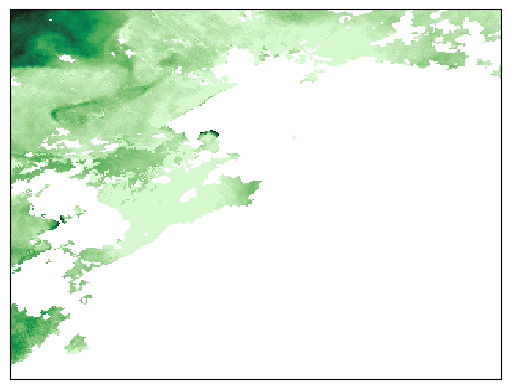

In [50]:
plt.figure()
ax1  = plt.subplot(111, projection=ccrs.PlateCarree())
field = ds_sat.CHL.squeeze()
cmap = cmocean.cm.algae
#cbar_label = r'Chl. ($mg/m^3$)'
vmin = 0.05 #np.nanpercentile(field, 5) #np.percentile(field[np.isfinite(field)],5)
vmax = 0.12 #np.nanpercentile(field, 95) #np.percentile(field[np.isfinite(field)],95)
cs = plt.pcolormesh(
    ds_sat.lon , ds_sat.lat, field,
    cmap = cmap,
    vmin = vmin,
    vmax = vmax,
    transform=ccrs.PlateCarree(),
    shading='auto',
    )

<a id="2.1"></a> <br>
## 2.1. SVP-B drifters:

<a id="2.1.1."></a> <br>
### 2.1.1. Full trajectories (zoom):

KeyError: 'instrument_model'

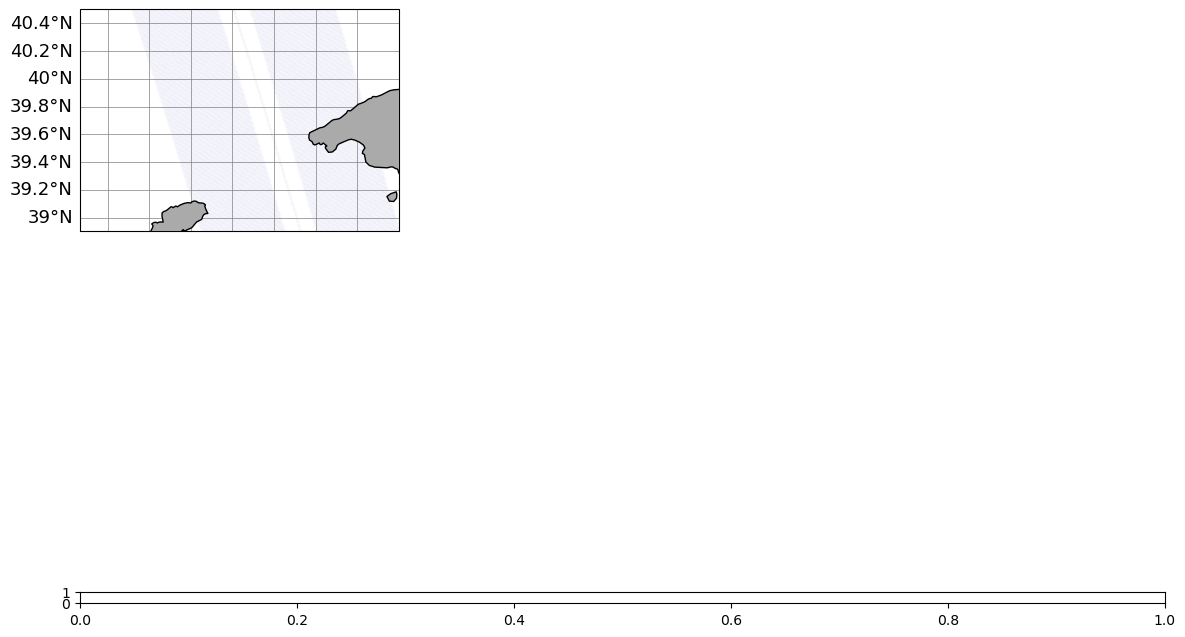

In [27]:
aa = 0 # axes index

plt.close()
plt.cla
plt.clf

gs_x = 3
gs_y = 3

############
fig = plt.figure(figsize=(14,8))

gs  = gridspec.GridSpec(gs_x, gs_y, height_ratios=[.49, .49, .02])
axC = plt.subplot(gs[-1,:])


######
# Leg1 

# fig, ax = plt.subplots(2, 3, sharex = 'col', sharey = 'row', figsize = (9, 6))
# fig.tight_layout(pad =3.0)

## SVP-B:
for ii, ds in enumerate(ds_svp_leg1):

    ax1  = plt.subplot(gs[aa], projection=ccrs.PlateCarree())
    cs = FaSt_SWOT_features(ax1, aa, ds, gs_x, gs_y, ds_sat, field='Chl') 

    #     ds_d07 = ds.sel(time=np.logical_and(ds.time.dt.day > last_day-1, ds.time.dt.day < last_day+1))
    #     ds_m05d07 = ds_d07.sel(time=np.logical_and(ds_d07.time.dt.month > 4, ds_d07.time.dt.month < 6))

    #     if ds_m05d07.time.shape[0] == 0 :
    #         print('No drifter data: ' + svp_leg1_n[ii] + ' ' + str(ds_m05d07.attrs['instrument_serial']))
    #         continue
    #     else:
    ax1.plot(ds.LON, ds.LAT, transform=ccrs.PlateCarree(), c='C0') 
    ax1.scatter(ds.LON[-1], ds.LAT[-1], c='C0', edgecolor='w', linewidths=0.8, transform=ccrs.PlateCarree())
        
    aa+=1
######

cbar = plt.colorbar(cs,
            cax=axC,
            orientation='horizontal',
            extend='both',
            #shrink=0.6,
            #     ticks=np.linspace(vmin,vmax,6),
            format='%3.2f'
            )

cbar_label = r'Chl. ($mg/m^3$)'
cbar.ax.tick_params(labelsize=12)
cbar.ax.set_xlabel(cbar_label, fontsize=12)

# plt.tight_layout()
plt.suptitle('Drifter trajectories + 06/05/2023 Chl. field', size=16);

plt.savefig('figures/' + 'SVP-B_drifters_L1_corr_FullTraj_Chl_060523.png', dpi=300)

plt.show()


<a id="2.1.2."></a> <br>
### 2.1.2. Full trajectories (full map extent):

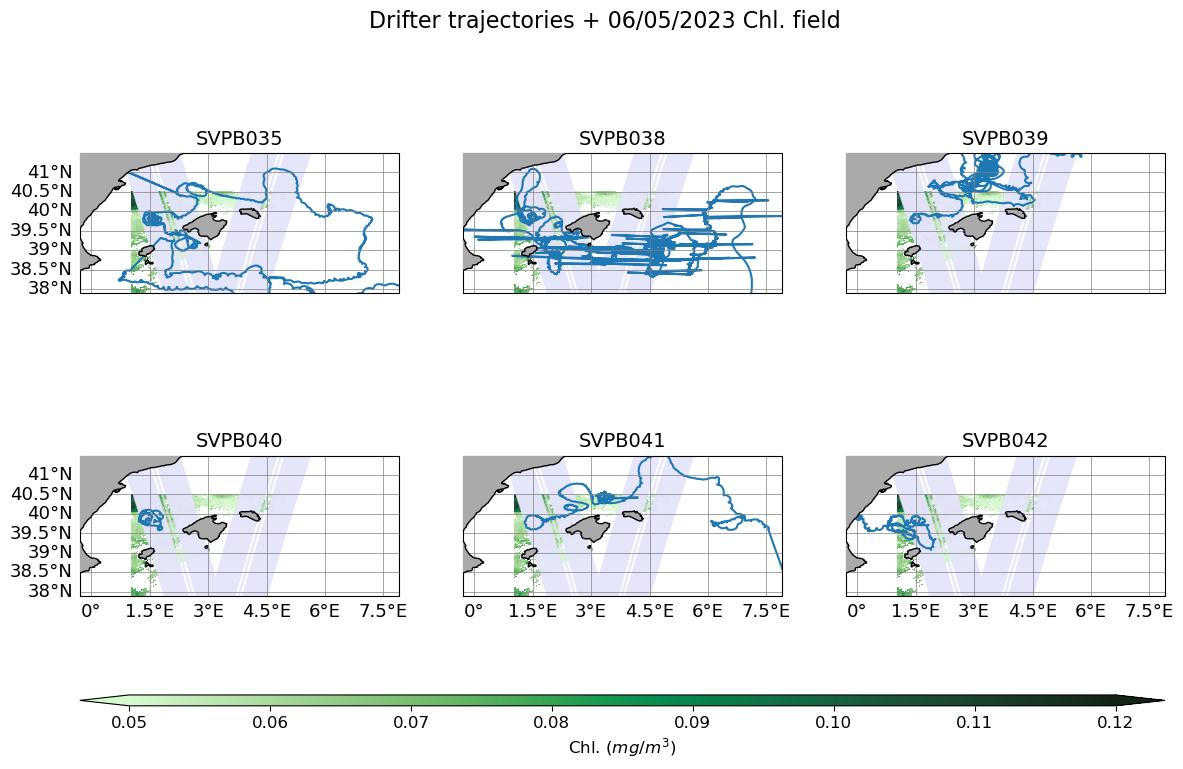

In [81]:
aa = 0 # axes index

plt.close()
plt.cla
plt.clf

gs_x = 3
gs_y = 3

############
fig = plt.figure(figsize=(14,8))

gs  = gridspec.GridSpec(gs_x, gs_y, height_ratios=[.49, .49, .02])
axC = plt.subplot(gs[-1,:])


######
# Leg1 

# fig, ax = plt.subplots(2, 3, sharex = 'col', sharey = 'row', figsize = (9, 6))
# fig.tight_layout(pad =3.0)

## SVP-B:
for ii, ds in enumerate(ds_svp_leg1):

    ax1  = plt.subplot(gs[aa], projection=ccrs.PlateCarree())
    cs = FaSt_SWOT_features(ax1, aa, ds, gs_x, gs_y, ds_sat, field='Chl', sub_uneq=0, map_extent=[-0.3, 7.9, 37.9, 41.5]) # Plotting SST

    #     ds_d07 = ds.sel(time=np.logical_and(ds.time.dt.day > last_day-1, ds.time.dt.day < last_day+1))
    #     ds_m05d07 = ds_d07.sel(time=np.logical_and(ds_d07.time.dt.month > 4, ds_d07.time.dt.month < 6))

    #     if ds_m05d07.time.shape[0] == 0 :
    #         print('No drifter data: ' + svp_leg1_n[ii] + ' ' + str(ds_m05d07.attrs['instrument_serial']))
    #         continue
    #     else:
    ax1.plot(ds.LON, ds.LAT, transform=ccrs.PlateCarree(), c='C0') 
    ax1.scatter(ds.LON[-1], ds.LAT[-1], c='C0', edgecolor='w', linewidths=0.8, transform=ccrs.PlateCarree())
        
    aa+=1
######

cbar = plt.colorbar(cs,
            cax=axC,
            orientation='horizontal',
            extend='both',
            #shrink=0.6,
            #     ticks=np.linspace(vmin,vmax,6),
            format='%3.2f'
            )

cbar_label = r'Chl. ($mg/m^3$)'
cbar.ax.tick_params(labelsize=12)
cbar.ax.set_xlabel(cbar_label, fontsize=12)

# plt.tight_layout()
plt.suptitle('Drifter trajectories + 06/05/2023 Chl. field', size=16);
# plt.savefig('figures/' + 'SVP-B_drifters_L1_corr_FullTraj_Chl_060523.png', dpi=300)

<a id="2.1.3."></a> <br>
### 2.1.3. Full trajectories (traj. extent):


/opt/anaconda3/envs/venv_fswot/lib/python3.11/site-packages/cartopy/mpl/geoaxes.py:874: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  self.set_ylim([y1, y2])


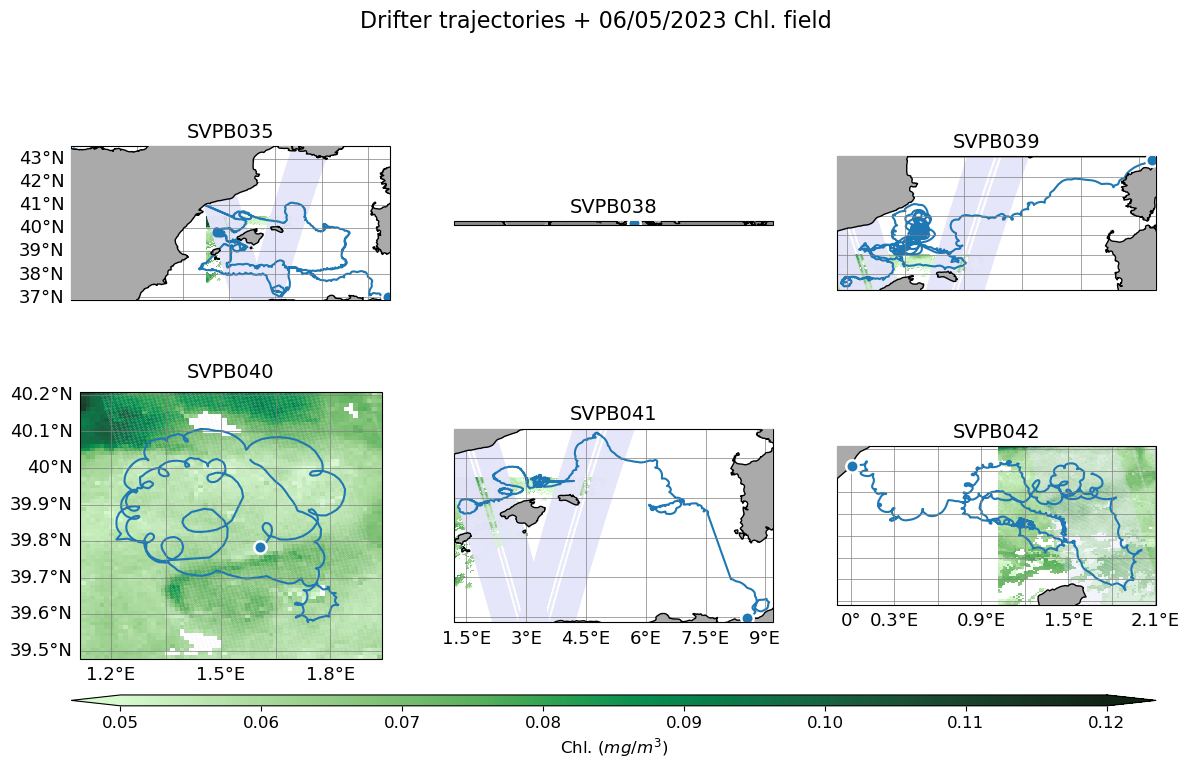

In [82]:
aa = 0 # axes index

plt.close()
plt.cla
plt.clf

gs_x = 3
gs_y = 3

############
fig = plt.figure(figsize=(14,8))

gs  = gridspec.GridSpec(gs_x, gs_y, height_ratios=[.49, .49, .02])
axC = plt.subplot(gs[-1,:])


######
# Leg1 

# fig, ax = plt.subplots(2, 3, sharex = 'col', sharey = 'row', figsize = (9, 6))
# fig.tight_layout(pad =3.0)

## SVP-B:
for ii, ds in enumerate(ds_svp_leg1):

    ax1  = plt.subplot(gs[aa], projection=ccrs.PlateCarree())
    map_es = [ds.LON.min().values -.1, ds.LON.max().values +.1, 
              ds.LAT.min().values -.1, ds.LAT.max().values +.1]
    cs = FaSt_SWOT_features(ax1, aa, ds, gs_x, gs_y, ds_sat, field='Chl', sub_uneq=0, map_extent=map_es) # Plotting SST

    #     ds_d07 = ds.sel(time=np.logical_and(ds.time.dt.day > last_day-1, ds.time.dt.day < last_day+1))
    #     ds_m05d07 = ds_d07.sel(time=np.logical_and(ds_d07.time.dt.month > 4, ds_d07.time.dt.month < 6))

    #     if ds_m05d07.time.shape[0] == 0 :
    #         print('No drifter data: ' + svp_leg1_n[ii] + ' ' + str(ds_m05d07.attrs['instrument_serial']))
    #         continue
    #     else:
    ax1.plot(ds.LON, ds.LAT, transform=ccrs.PlateCarree(), c='C0') 
    ax1.scatter(ds.LON[-1], ds.LAT[-1], s=80, c='C0', edgecolor='w', linewidths=1.8,
                zorder=500, transform=ccrs.PlateCarree())
        
    aa+=1
######

cbar = plt.colorbar(cs,
            cax=axC,
            orientation='horizontal',
            extend='both',
            #shrink=0.6,
            #     ticks=np.linspace(vmin,vmax,6),
            format='%3.2f'
            )

cbar_label = r'Chl. ($mg/m^3$)'
cbar.ax.tick_params(labelsize=12)
cbar.ax.set_xlabel(cbar_label, fontsize=12)

# plt.tight_layout()
plt.suptitle('Drifter trajectories + 06/05/2023 Chl. field', size=16);
# plt.savefig('figures/' + 'SVP-B_drifters_L1_corr_FullTraj_Zoom_Chl_060523.png', dpi=300)

<a id="2.1.4."></a> <br>
### 2.1.4. Only trajectory on day 06/05/23 (+/- 1 day):

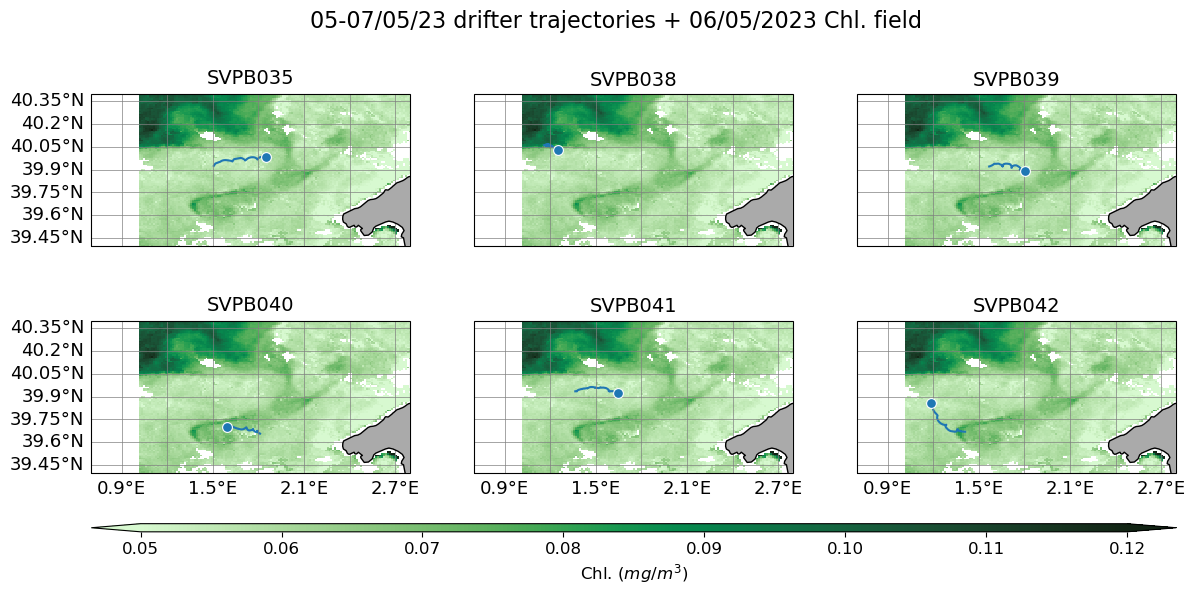

In [90]:
dd1 = '05'
dd2 = '07'

aa = 0 # axes index

plt.close()
plt.cla
plt.clf

gs_x = 3
gs_y = 3

############
fig = plt.figure(figsize=(14, 6))

gs  = gridspec.GridSpec(gs_x, gs_y, height_ratios=[.49, .49, .02])
axC = plt.subplot(gs[-1,:])


######
# Leg1 

# fig, ax = plt.subplots(2, 3, sharex = 'col', sharey = 'row', figsize = (9, 6))
# fig.tight_layout(pad =3.0)

## SVP-B:
for ii, ds in enumerate(ds_svp_leg1):
    ax1  = plt.subplot(gs[aa], projection=ccrs.PlateCarree())
    map_es = [ds.LON.min().values -.1, ds.LON.max().values +.1, 
              ds.LAT.min().values -.1, ds.LAT.max().values +.1]
    
    cs = FaSt_SWOT_features(ax1, aa, ds, gs_x, gs_y, ds_sat, field='Chl', map_extent=[0.7, 2.8, 39.4, 40.4], sub_uneq=0, SWOT_swath=False)
    
    ds_s = ds.sel(time=slice("2023-05-"+dd1, "2023-05-"+dd2))
    if ds_s.time.size == 0:
        print('No trajectory segment on these days')
        #continue
    else:
        ax1.plot(ds_s.LON, ds_s.LAT, transform=ccrs.PlateCarree(), c='C0') 
        ax1.scatter(ds_s.LON[-1], ds_s.LAT[-1], s=50, c='C0', edgecolor='w', linewidths=0.8,
               zorder=500, transform=ccrs.PlateCarree())

    aa+=1
######

cbar = plt.colorbar(cs,
            cax=axC,
            orientation='horizontal',
            extend='both',
            #shrink=0.6,
            #     ticks=np.linspace(vmin,vmax,6),
            format='%3.2f'
            )

cbar_label = r'Chl. ($mg/m^3$)'
cbar.ax.tick_params(labelsize=12)
cbar.ax.set_xlabel(cbar_label, fontsize=12)

# plt.tight_layout()
plt.suptitle(dd1 + '-' + dd2 + '/05/23 drifter trajectories + 06/05/2023 Chl. field', size=16);

# plt.savefig('figures/' + 'SVP-B_drifters_L1_corr_1d_win_ZoomC_Chl_060523.png', dpi=300)

<a id="2.1.5."></a> <br>
### 2.1.5. Full trajectories (regional zoom) + Highlight of trajectory on day 15/05/23 (+/- 1 day):

In [91]:
# aa = 0 # axes index

# plt.close()
# plt.cla
# plt.clf

# gs_x = 3
# gs_y = 3

# ############
# fig = plt.figure(figsize=(14, 8))

# gs  = gridspec.GridSpec(gs_x, gs_y, height_ratios=[.49, .49, .02])
# axC = plt.subplot(gs[-1,:])


# ######
# # Leg1 

# # fig, ax = plt.subplots(2, 3, sharex = 'col', sharey = 'row', figsize = (9, 6))
# # fig.tight_layout(pad =3.0)

# ## SVP-B:
# for ii, ds in enumerate(ds_svp_leg1):
#     ax1  = plt.subplot(gs[aa], projection=ccrs.PlateCarree())
#     map_es = [ds.LON.min().values -.1, ds.LON.max().values +.1, 
#               ds.LAT.min().values -.1, ds.LAT.max().values +.1]
    
#     cs = FaSt_SWOT_features(ax1, aa, ds_s, gs_x, gs_y, field=True, sub_uneq=2)

#     ax1.plot(ds.LON, ds.LAT, transform=ccrs.PlateCarree(), c='C0') 
#     ax1.scatter(ds.LON[-1], ds.LAT[-1], s=50, c='C0', edgecolor='w', linewidths=0.8,
#                zorder=500, transform=ccrs.PlateCarree())
    
#     ds_s = ds.sel(time=slice("2023-05-14", "2023-05-16"))
#     if ds_s.time.size == 0:
#         print('No trajectory segment on these days')
#         #continue
#     else:
#         ax1.plot(ds_s.LON, ds_s.LAT, transform=ccrs.PlateCarree(), c='b', label='Traj. 14-16/05') 
#         if aa==0:
#             ax1.legend(loc=2)
    
#     aa+=1
# ######

# cbar = plt.colorbar(cs,
#             cax=axC,
#             orientation='horizontal',
#             extend='both',
#             #shrink=0.6,
#             #     ticks=np.linspace(vmin,vmax,6),
#             format='%3.2f'
#             )
# cbar_label = r'SST ($^{\circ}$C)'
# cbar.ax.tick_params(labelsize=12)
# cbar.ax.set_xlabel(cbar_label, fontsize=12)

# # plt.tight_layout()
# plt.suptitle('15/05/2023 Drifter trajectories + SST field', size=16);

# # plt.savefig('CARTHE1_drifters_150523_15h_SST_150523.png', dpi=300)

<a id="2.2."></a> <br>
## 2.2. CARTHE:

<a id="2.2.1."></a> <br>
### 2.2.1. Full trajectories (regional zoom):

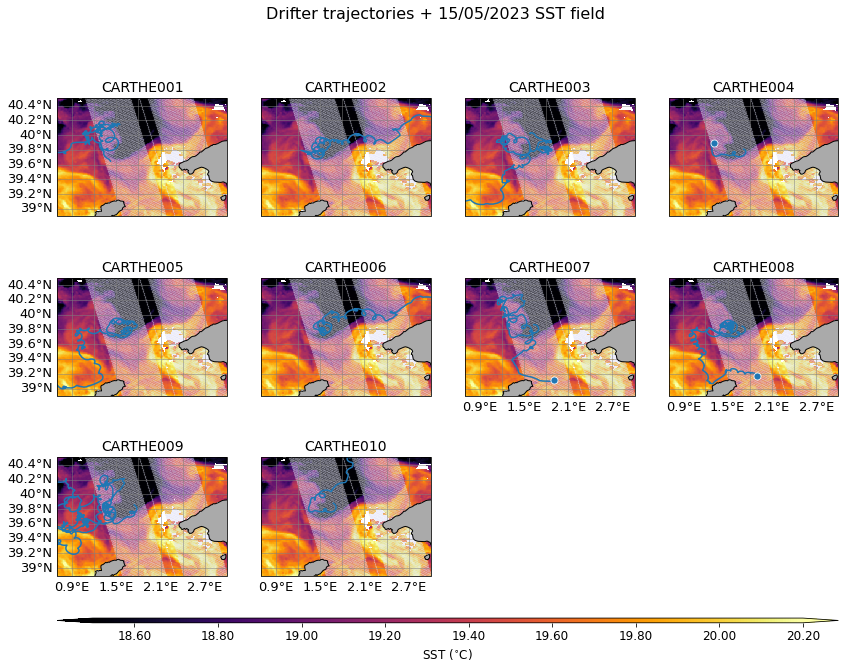

In [66]:
aa = 0 # axes index

plt.close()
plt.cla
plt.clf

gs_x = 4
gs_y = 4

############
fig = plt.figure(figsize=(14,10))

gs  = gridspec.GridSpec(gs_x, gs_y, height_ratios=[.33, .33, .33, .01])
axC = plt.subplot(gs[-1,:])


######
# Leg1 

# fig, ax = plt.subplots(2, 3, sharex = 'col', sharey = 'row', figsize = (9, 6))
# fig.tight_layout(pad =3.0)

## SVP-B:
for ii, ds in enumerate(ds_car_leg1):
    ax1  = plt.subplot(gs[aa], projection=ccrs.PlateCarree())
    cs = FaSt_SWOT_features(ax1, aa, ds, gs_x, gs_y, field=True, sub_uneq=2)

    #     ds_d07 = ds.sel(time=np.logical_and(ds.time.dt.day > last_day-1, ds.time.dt.day < last_day+1))
    #     ds_m05d07 = ds_d07.sel(time=np.logical_and(ds_d07.time.dt.month > 4, ds_d07.time.dt.month < 6))

    #     if ds_m05d07.time.shape[0] == 0 :
    #         print('No drifter data: ' + svp_leg1_n[ii] + ' ' + str(ds_m05d07.attrs['instrument_serial']))
    #         continue
    #     else:
    ax1.plot(ds.LON, ds.LAT, transform=ccrs.PlateCarree(), c='C0') 
    ax1.scatter(ds.LON[-1], ds.LAT[-1], s=50, c='C0', edgecolor='w', linewidths=0.8,
                zorder=500, transform=ccrs.PlateCarree())
        
    aa+=1
######

cbar = plt.colorbar(cs,
            cax=axC,
            orientation='horizontal',
            extend='both',
            #shrink=0.6,
            #     ticks=np.linspace(vmin,vmax,6),
            format='%3.2f'
            )
cbar_label = r'SST ($^{\circ}$C)'
cbar.ax.tick_params(labelsize=12)
cbar.ax.set_xlabel(cbar_label, fontsize=12)

# plt.tight_layout()
plt.suptitle('Drifter trajectories + 15/05/2023 SST field', size=16);

plt.savefig('CARTHE1_drifters_FullTraj_SST_150523_upd01.png', dpi=300) 
# plt.savefig('CARTHE1_drifters_150523_15h_SST_150523.png', dpi=300)
# plt.savefig('CARTHE1_drifters_FullTraj_SST_150523.png', dpi=300) #6th June 2023
# plt.savefig('CARTHE1_drifters_160523_17h45_SST_150523.png', dpi=300)
# plt.savefig('CARTHE1_drifters_170523_17h20_SST_150523.png', dpi=300)

<a id="2.2.2."></a> <br>
### 2.2.2. Full trajectories (full map extent):

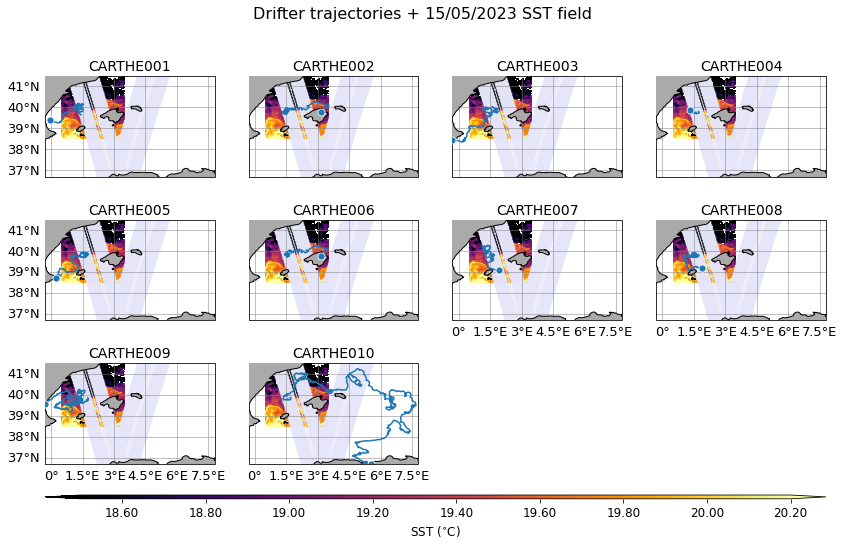

In [40]:
aa = 0 # axes index

plt.close()
plt.cla
plt.clf

gs_x = 4
gs_y = 4

############
fig = plt.figure(figsize=(14, 8))

gs  = gridspec.GridSpec(gs_x, gs_y, height_ratios=[.33, .33, .33, .01])
axC = plt.subplot(gs[-1,:])


######
# Leg1 

# fig, ax = plt.subplots(2, 3, sharex = 'col', sharey = 'row', figsize = (9, 6))
# fig.tight_layout(pad =3.0)

## SVP-B:
for ii, ds in enumerate(ds_car_leg1):
    ax1  = plt.subplot(gs[aa], projection=ccrs.PlateCarree())
    cs = FaSt_SWOT_features(ax1, aa, ds, gs_x, gs_y, field=True, map_extent=[-0.3, 7.8, 36.7, 41.5], sub_uneq=2)

    #     ds_d07 = ds.sel(time=np.logical_and(ds.time.dt.day > last_day-1, ds.time.dt.day < last_day+1))
    #     ds_m05d07 = ds_d07.sel(time=np.logical_and(ds_d07.time.dt.month > 4, ds_d07.time.dt.month < 6))

    #     if ds_m05d07.time.shape[0] == 0 :
    #         print('No drifter data: ' + svp_leg1_n[ii] + ' ' + str(ds_m05d07.attrs['instrument_serial']))
    #         continue
    #     else:
    ax1.plot(ds.LON, ds.LAT, transform=ccrs.PlateCarree(), c='C0') 
    ax1.scatter(ds.LON[-1], ds.LAT[-1], s=50, c='C0', edgecolor='w', linewidths=0.8,
                zorder=500, transform=ccrs.PlateCarree())
        
    aa+=1
######

cbar = plt.colorbar(cs,
            cax=axC,
            orientation='horizontal',
            extend='both',
            #shrink=0.6,
            #     ticks=np.linspace(vmin,vmax,6),
            format='%3.2f'
            )
cbar_label = r'SST ($^{\circ}$C)'
cbar.ax.tick_params(labelsize=12)
cbar.ax.set_xlabel(cbar_label, fontsize=12)

# plt.tight_layout()
plt.suptitle('Drifter trajectories + 15/05/2023 SST field', size=16);

# plt.savefig('CARTHE1_drifters_150523_15h_SST_150523.png', dpi=300)

<a id="2.2.3."></a> <br>
### 2.2.3. Full trajectories (traj. extent):


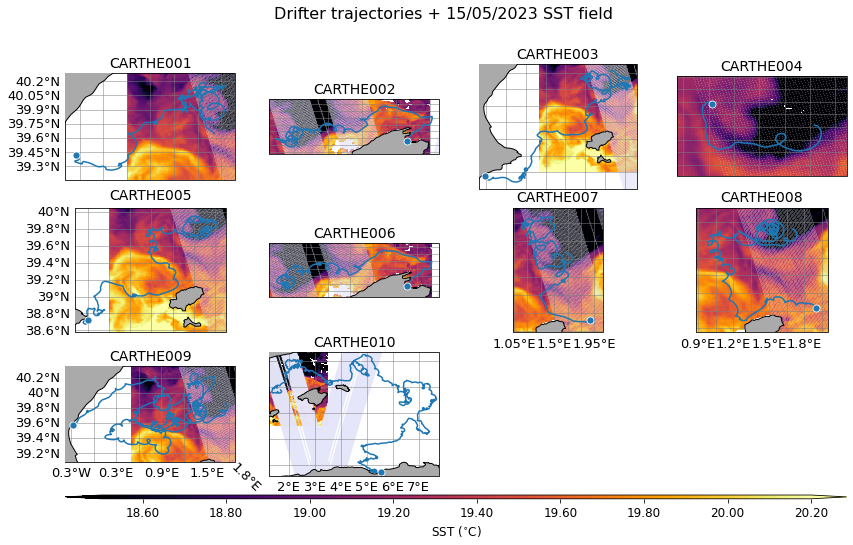

In [41]:
aa = 0 # axes index

plt.close()
plt.cla
plt.clf

gs_x = 4
gs_y = 4

############
fig = plt.figure(figsize=(14, 8))

gs  = gridspec.GridSpec(gs_x, gs_y, height_ratios=[.33, .33, .33, .01])
axC = plt.subplot(gs[-1,:])


######
# Leg1 

# fig, ax = plt.subplots(2, 3, sharex = 'col', sharey = 'row', figsize = (9, 6))
# fig.tight_layout(pad =3.0)

## SVP-B:
for ii, ds in enumerate(ds_car_leg1):
    ax1  = plt.subplot(gs[aa], projection=ccrs.PlateCarree())
    map_es = [ds.LON.min().values -.1, ds.LON.max().values +.1, 
              ds.LAT.min().values -.1, ds.LAT.max().values +.1]
    cs = FaSt_SWOT_features(ax1, aa, ds, gs_x, gs_y, field=True, map_extent=map_es, sub_uneq=2)

    #     ds_d07 = ds.sel(time=np.logical_and(ds.time.dt.day > last_day-1, ds.time.dt.day < last_day+1))
    #     ds_m05d07 = ds_d07.sel(time=np.logical_and(ds_d07.time.dt.month > 4, ds_d07.time.dt.month < 6))

    #     if ds_m05d07.time.shape[0] == 0 :
    #         print('No drifter data: ' + svp_leg1_n[ii] + ' ' + str(ds_m05d07.attrs['instrument_serial']))
    #         continue
    #     else:
    ax1.plot(ds.LON, ds.LAT, transform=ccrs.PlateCarree(), c='C0') 
    ax1.scatter(ds.LON[-1], ds.LAT[-1], s=50, c='C0', edgecolor='w', linewidths=0.8,
                zorder=500, transform=ccrs.PlateCarree())
        
    aa+=1
######

cbar = plt.colorbar(cs,
            cax=axC,
            orientation='horizontal',
            extend='both',
            #shrink=0.6,
            #     ticks=np.linspace(vmin,vmax,6),
            format='%3.2f'
            )
cbar_label = r'SST ($^{\circ}$C)'
cbar.ax.tick_params(labelsize=12)
cbar.ax.set_xlabel(cbar_label, fontsize=12)

# plt.tight_layout()
plt.suptitle('Drifter trajectories + 15/05/2023 SST field', size=16);

# plt.savefig('CARTHE1_drifters_150523_15h_SST_150523.png', dpi=300)

<a id="2.2.4."></a> <br>
### 2.2.4. Only trajectory on day 15/05/23 (+/- 1 day):

NameError: name 'ds_car_leg1' is not defined

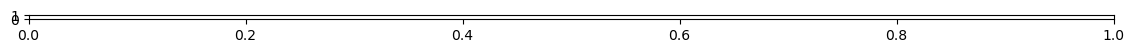

In [37]:
dd1 = '05'
dd2 = '07'

aa = 0 # axes index

plt.close()
plt.cla
plt.clf

gs_x = 4
gs_y = 4

############
fig = plt.figure(figsize=(14, 6))

gs  = gridspec.GridSpec(gs_x, gs_y, height_ratios=[.33, .33, .33, .01])
axC = plt.subplot(gs[-1,:])


######
# Leg1 

# fig, ax = plt.subplots(2, 3, sharex = 'col', sharey = 'row', figsize = (9, 6))
# fig.tight_layout(pad =3.0)

## SVP-B:
for ii, ds in enumerate(ds_car_leg1):
    ax1  = plt.subplot(gs[aa], projection=ccrs.PlateCarree())
    map_es = [ds.LON.min().values -.1, ds.LON.max().values +.1, 
              ds.LAT.min().values -.1, ds.LAT.max().values +.1]
    
    cs = FaSt_SWOT_features(ax1, aa, ds, gs_x, gs_y, ds_sat, field='Chl', map_extent=[0.9, 3.65, 39.4, 40.4], sub_uneq=2, SWOT_swath=False)
    
    ds_s = ds.sel(time=slice("2023-05-"+dd1, "2023-05-"+dd2))
    if ds_s.time.size == 0:
        print('No trajectory segment on these days')
        #continue
    else:
        ax1.plot(ds_s.LON, ds_s.LAT, transform=ccrs.PlateCarree(), c='C0') 
        ax1.scatter(ds_s.LON[-1], ds_s.LAT[-1], s=50, c='C0', edgecolor='w', linewidths=0.8,
               zorder=500, transform=ccrs.PlateCarree())

    aa+=1
######

cbar = plt.colorbar(cs,
            cax=axC,
            orientation='horizontal',
            extend='both',
            #shrink=0.6,
            #     ticks=np.linspace(vmin,vmax,6),
            format='%3.2f'
            )
cbar_label = r'Chl. ($mg/m^3$)'
cbar.ax.tick_params(labelsize=12)
cbar.ax.set_xlabel(cbar_label, fontsize=12)

# plt.tight_layout()
plt.suptitle(dd1 + '-' + dd2 + '/05/23 drifter trajectories + 06/05/23 Chl. field', size=16);

# plt.savefig('figures/' + 'CARTHE1_drifters_1d_win_060523_Chl.png', dpi=300)

plt.show()

### Individual plots:

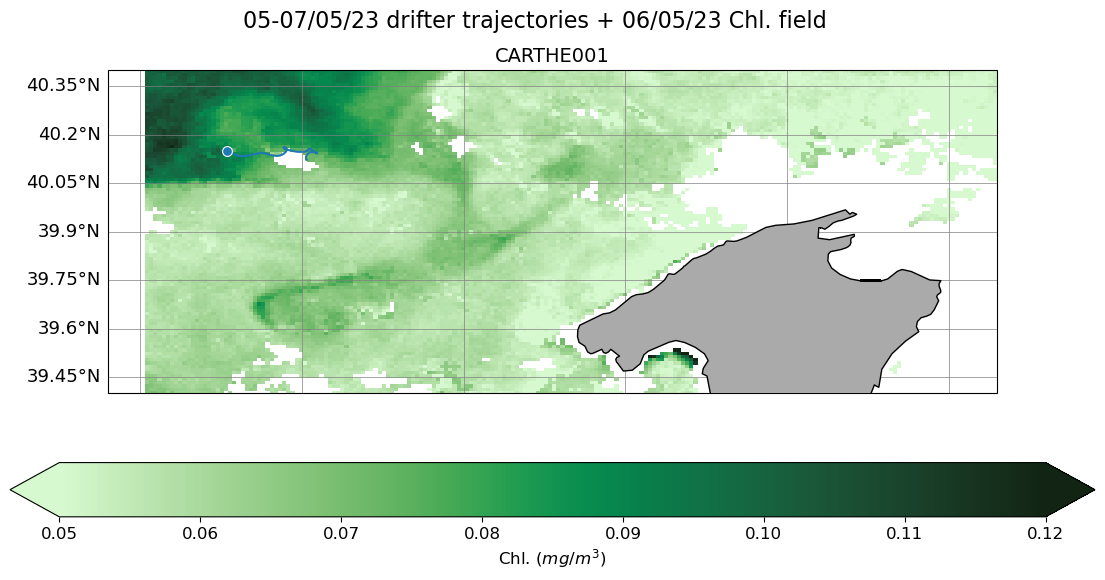

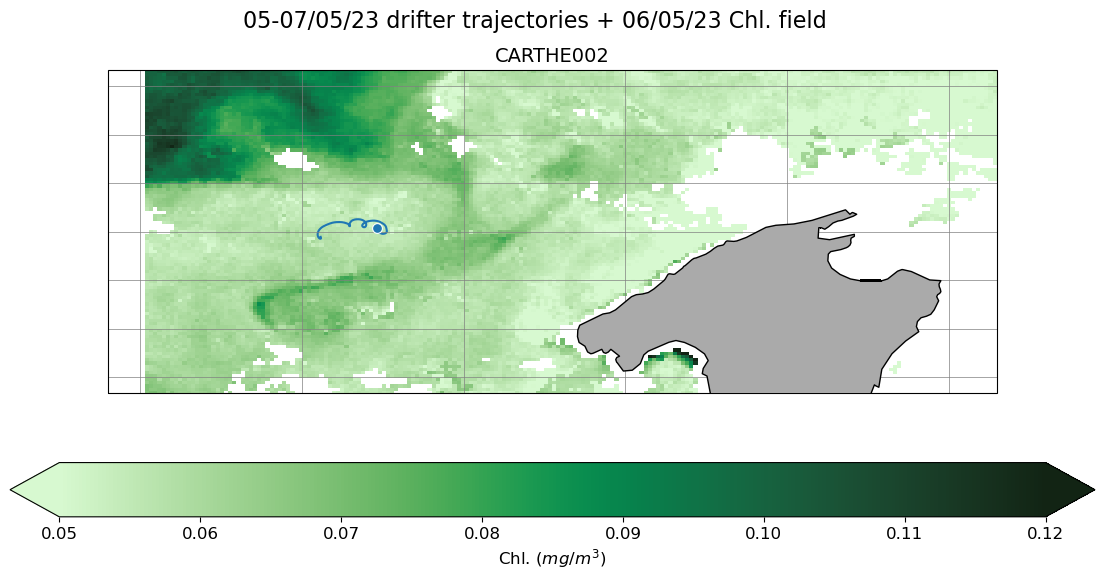

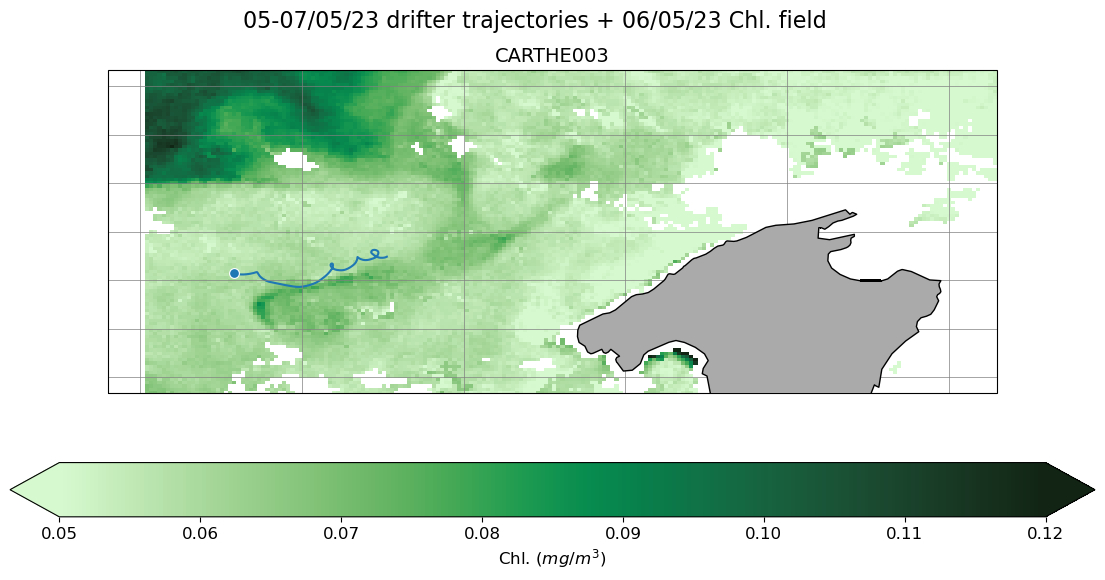

No trajectory segment on these days


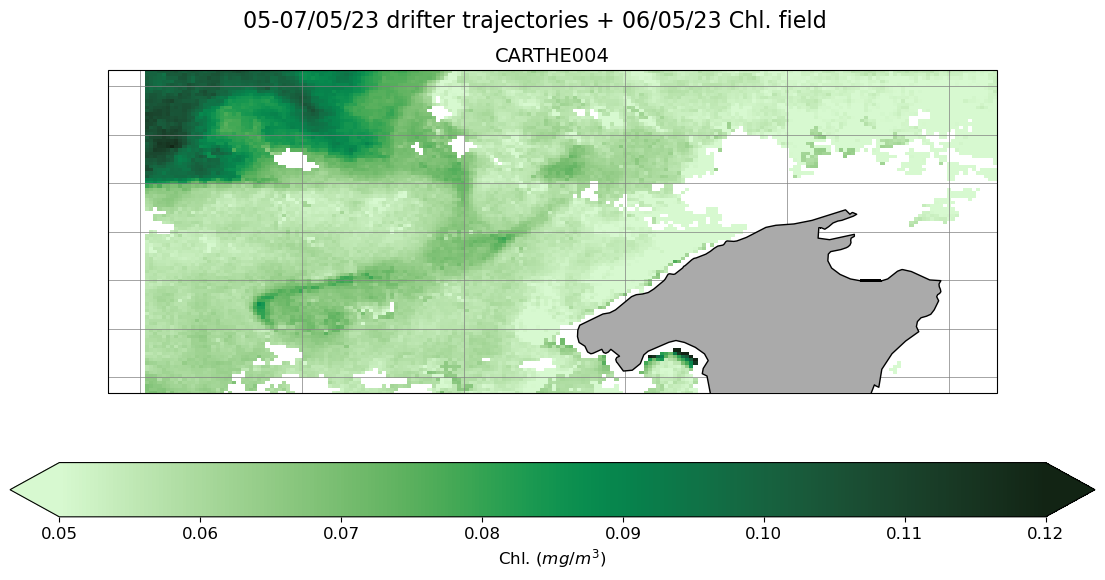

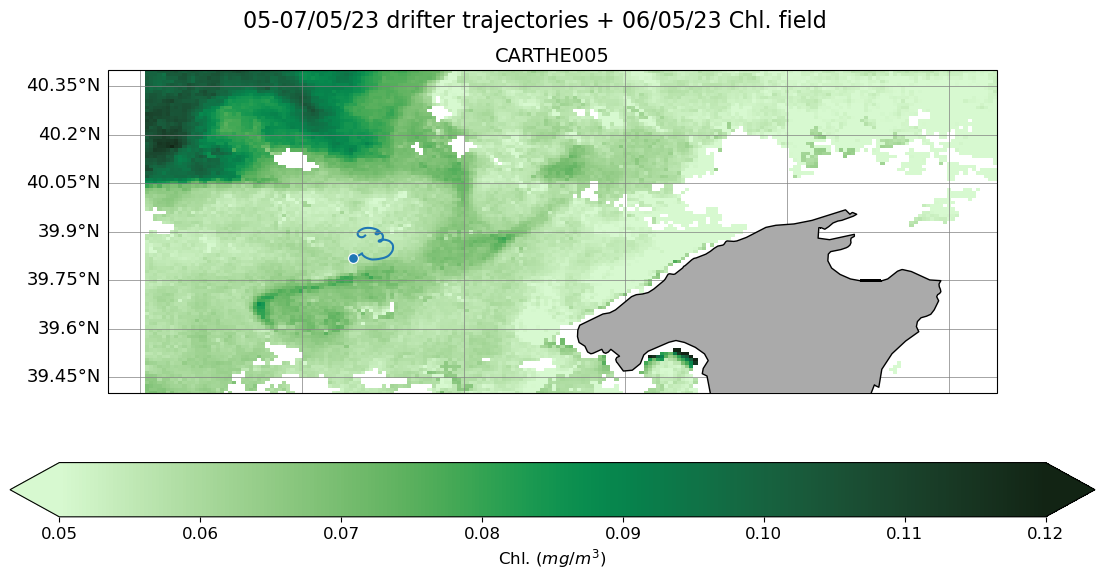

No trajectory segment on these days


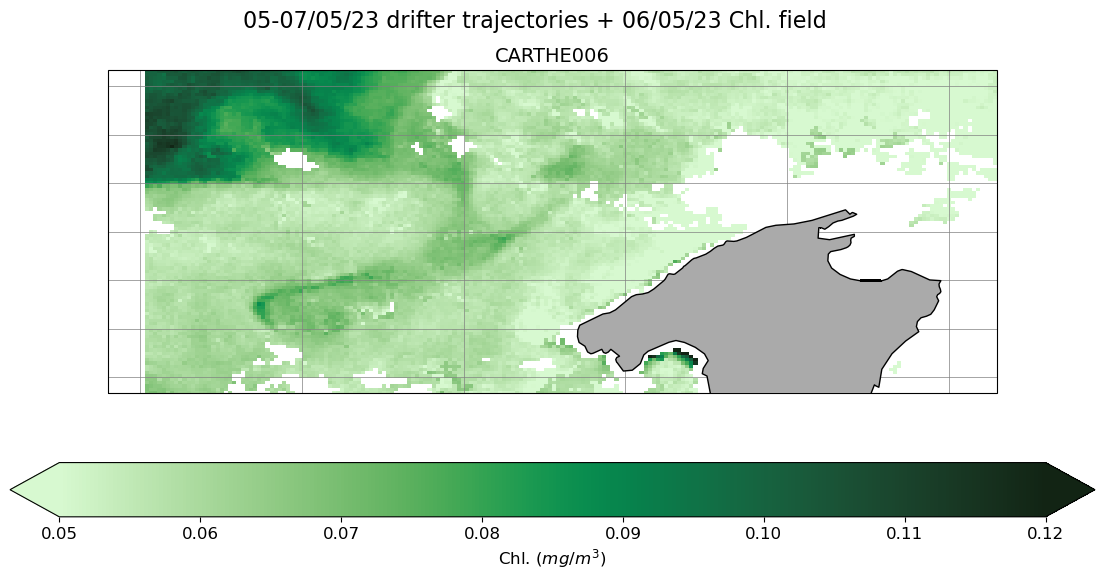

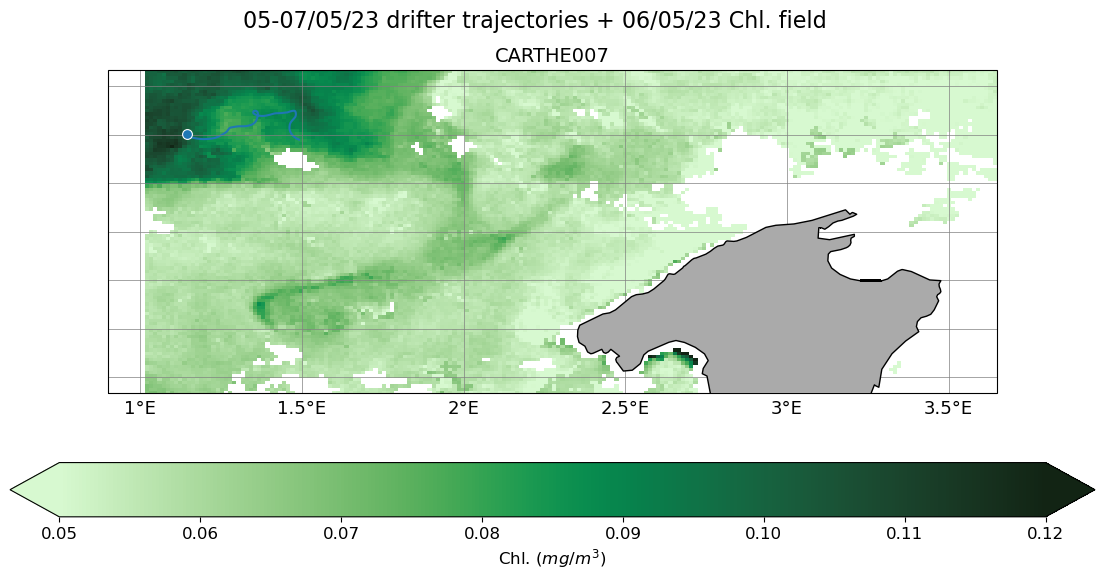

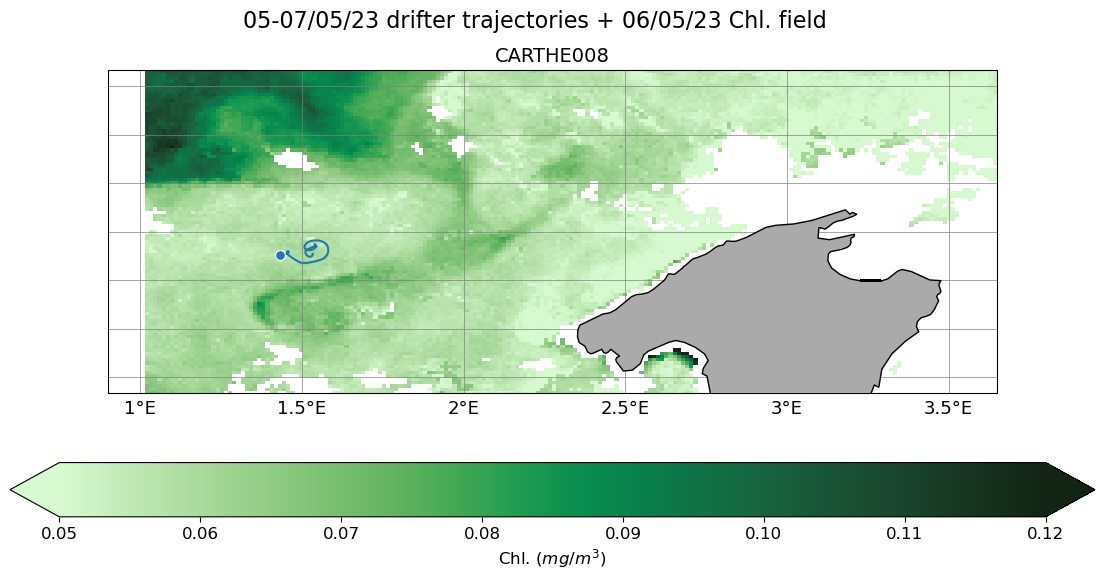

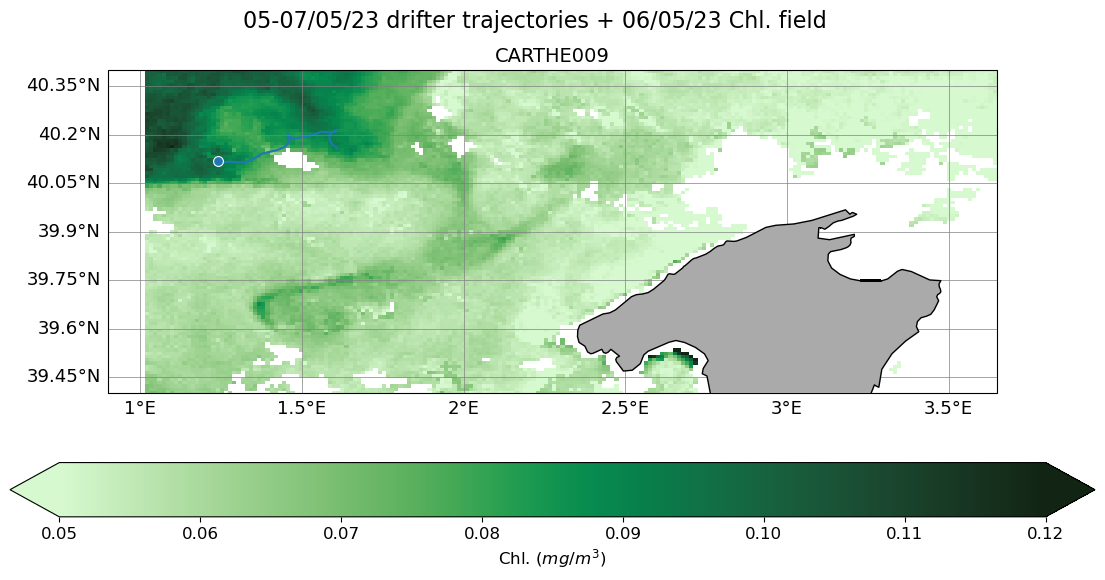

No trajectory segment on these days


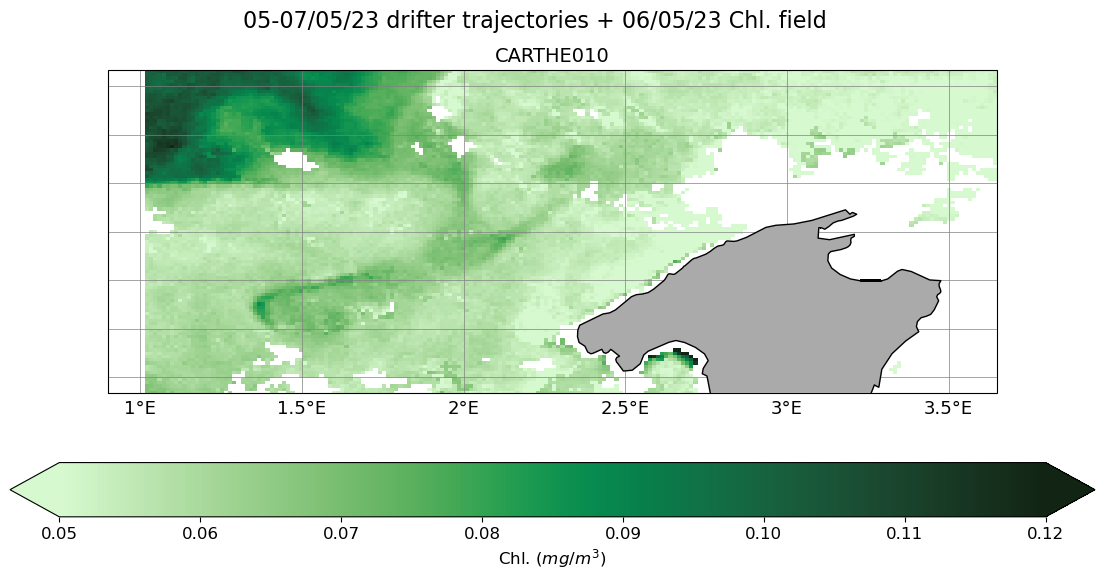

In [53]:
dd1 = '05'
dd2 = '07'

aa = 0 # axes index

######
# Leg1 

# fig, ax = plt.subplots(2, 3, sharex = 'col', sharey = 'row', figsize = (9, 6))
# fig.tight_layout(pad =3.0)

## SVP-B:
for ii, ds in enumerate(ds_car_leg1):
    plt.close()
    plt.cla
    plt.clf

    ############
    fig = plt.figure(figsize=(14, 6))

    ax1  = plt.subplot(111, projection=ccrs.PlateCarree())
    map_es = [ds.LON.min().values -.1, ds.LON.max().values +.1, 
              ds.LAT.min().values -.1, ds.LAT.max().values +.1]
    
    cs = FaSt_SWOT_features(ax1, aa, gs_x, gs_y, ds_sat, field='Chl', map_extent=[0.9, 3.65, 39.4, 40.4], sub_uneq=2, SWOT_swath=False)
    
    ds_s = ds.sel(time=slice("2023-05-"+dd1, "2023-05-"+dd2))
    if ds_s.time.size == 0:
        print('No trajectory segment on these days')
        #continue
    else:
        ax1.plot(ds_s.LON, ds_s.LAT, transform=ccrs.PlateCarree(), c='C0') 
        ax1.scatter(ds_s.LON[-1], ds_s.LAT[-1], s=50, c='C0', edgecolor='w', linewidths=0.8,
               zorder=500, transform=ccrs.PlateCarree())

    aa+=1
######

    cbar = plt.colorbar(cs,
                #cax=axC,
                orientation='horizontal',
                extend='both',
                #shrink=0.6,
                #     ticks=np.linspace(vmin,vmax,6),
                format='%3.2f'
                )
    cbar_label = r'Chl. ($mg/m^3$)'
    cbar.ax.tick_params(labelsize=12)
    cbar.ax.set_xlabel(cbar_label, fontsize=12)

    # plt.tight_layout()
    plt.suptitle(dd1 + '-' + dd2 + '/05/23 drifter trajectories + 06/05/23 Chl. field', size=16);

    # plt.savefig('CARTHE1_drifters_150523_15h_SST_150523.png', dpi=300)
    plt.show()

<a id="2.2.5."></a> <br>
### 2.2.5. Full trajectories (regional zoom) + Highlight of trajectory on day 15/05/23 (+/- 1 day):

No trajectory segment on these days


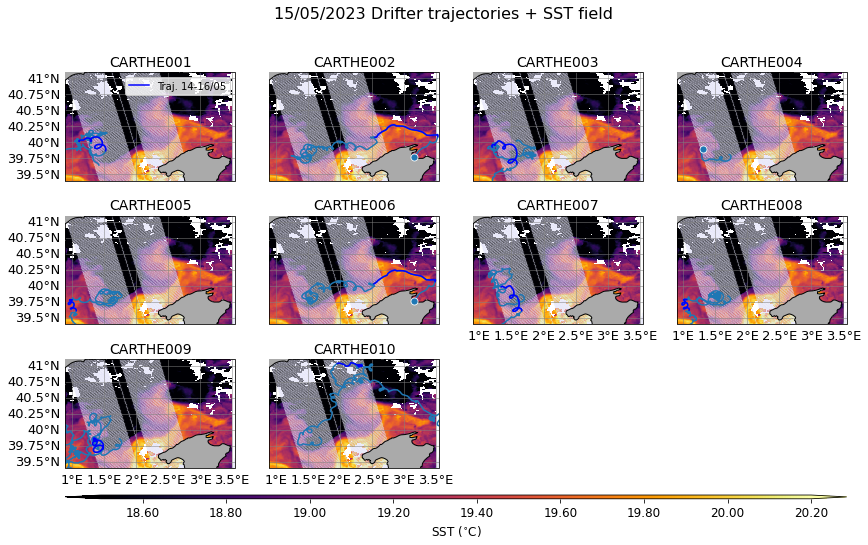

In [116]:
aa = 0 # axes index

plt.close()
plt.cla
plt.clf

gs_x = 4
gs_y = 4

############
fig = plt.figure(figsize=(14, 8))

gs  = gridspec.GridSpec(gs_x, gs_y, height_ratios=[.33, .33, .33, .01])
axC = plt.subplot(gs[-1,:])


######
# Leg1 

# fig, ax = plt.subplots(2, 3, sharex = 'col', sharey = 'row', figsize = (9, 6))
# fig.tight_layout(pad =3.0)

## SVP-B:
for ii, ds in enumerate(ds_car_leg1):
    ax1  = plt.subplot(gs[aa], projection=ccrs.PlateCarree())
    map_es = [ds.LON.min().values -.1, ds.LON.max().values +.1, 
              ds.LAT.min().values -.1, ds.LAT.max().values +.1]
    
    cs = FaSt_SWOT_features(ax1, aa, ds_s, gs_x, gs_y, field=True, map_extent=[0.9, 3.55, 39.4, 41.1], sub_uneq=2)

    ax1.plot(ds.LON, ds.LAT, transform=ccrs.PlateCarree(), c='C0') 
    ax1.scatter(ds.LON[-1], ds.LAT[-1], s=50, c='C0', edgecolor='w', linewidths=0.8,
               zorder=500, transform=ccrs.PlateCarree())
    
    ds_s = ds.sel(time=slice("2023-05-14", "2023-05-16"))
    if ds_s.time.size == 0:
        print('No trajectory segment on these days')
        #continue
    else:
        ax1.plot(ds_s.LON, ds_s.LAT, transform=ccrs.PlateCarree(), c='b', label='Traj. 14-16/05') 
        if aa==0:
            ax1.legend(loc=1)
    
    aa+=1
######

cbar = plt.colorbar(cs,
            cax=axC,
            orientation='horizontal',
            extend='both',
            #shrink=0.6,
            #     ticks=np.linspace(vmin,vmax,6),
            format='%3.2f'
            )
cbar_label = r'SST ($^{\circ}$C)'
cbar.ax.tick_params(labelsize=12)
cbar.ax.set_xlabel(cbar_label, fontsize=12)

# plt.tight_layout()
plt.suptitle('15/05/2023 Drifter trajectories + SST field', size=16);

# plt.savefig('CARTHE1_drifters_150523_15h_SST_150523.png', dpi=300)

<a id="2.3."></a> <br>
## 2.3. HEREON:

<a id="2.3.1."></a> <br>
### 2.3.1. Full trajectories (regional zoom):

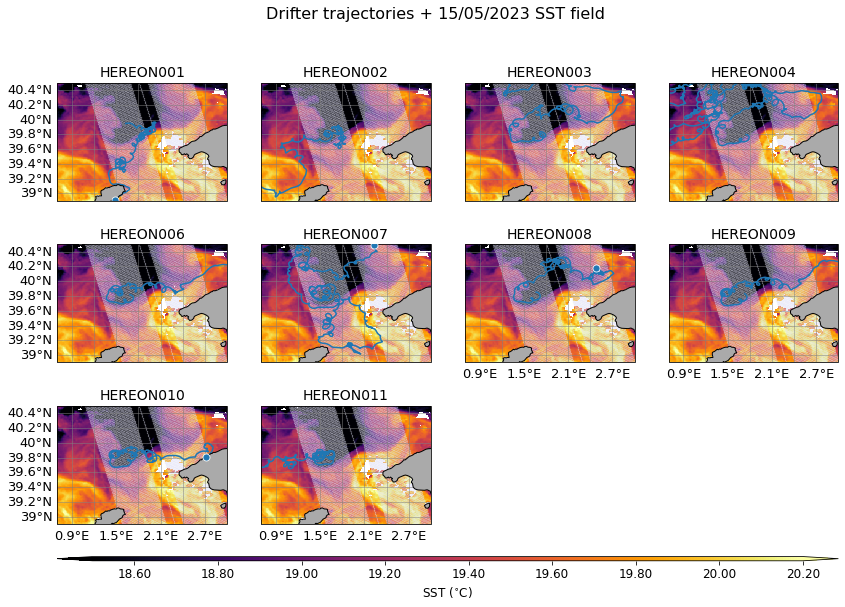

In [72]:
aa = 0 # axes index

plt.close()
plt.cla
plt.clf

gs_x = 4
gs_y = 4

############
fig = plt.figure(figsize=(14, 9))

gs  = gridspec.GridSpec(gs_x, gs_y, height_ratios=[.33, .33, .33, .01])
axC = plt.subplot(gs[-1,:])

######
# Leg1 

# fig, ax = plt.subplots(2, 3, sharex = 'col', sharey = 'row', figsize = (9, 6))
# fig.tight_layout(pad =3.0)

for ii, ds in enumerate(ds_her_leg1):
    ax1  = plt.subplot(gs[aa], projection=ccrs.PlateCarree())
    cs = FaSt_SWOT_features(ax1, aa, ds, gs_x, gs_y, field=True, sub_uneq=2)#, map_extent=[.7, 3.5, 38.7, 40.7])

    ax1.plot(ds.LON, ds.LAT, transform=ccrs.PlateCarree(), c='C0') 
    ax1.scatter(ds.LON[-1], ds.LAT[-1], s=50, c='C0', edgecolor='w', linewidths=0.8,
                zorder=500, transform=ccrs.PlateCarree())
        
    aa+=1
    
######

cbar = plt.colorbar(cs,
            cax=axC,
            orientation='horizontal',
            extend='both',
            #shrink=0.6,
            #     ticks=np.linspace(vmin,vmax,6),
            format='%3.2f'
            )
cbar_label = r'SST ($^{\circ}$C)'
cbar.ax.tick_params(labelsize=12)
cbar.ax.set_xlabel(cbar_label, fontsize=12)

# plt.tight_layout()
plt.suptitle('Drifter trajectories + 15/05/2023 SST field', size=16);

# plt.savefig('HEREON_drifters_150523_SST_150523.png', dpi=300)
# plt.savefig('HEREON1_drifters_FullTraj_SST_150523.png', dpi=300) #6th June 23
plt.savefig('HEREON1_drifters_FullTraj_SST_150523_upd01.png', dpi=300)


<a id="2.3.2."></a> <br>
### 2.3.2. Full trajectories (full map extent):

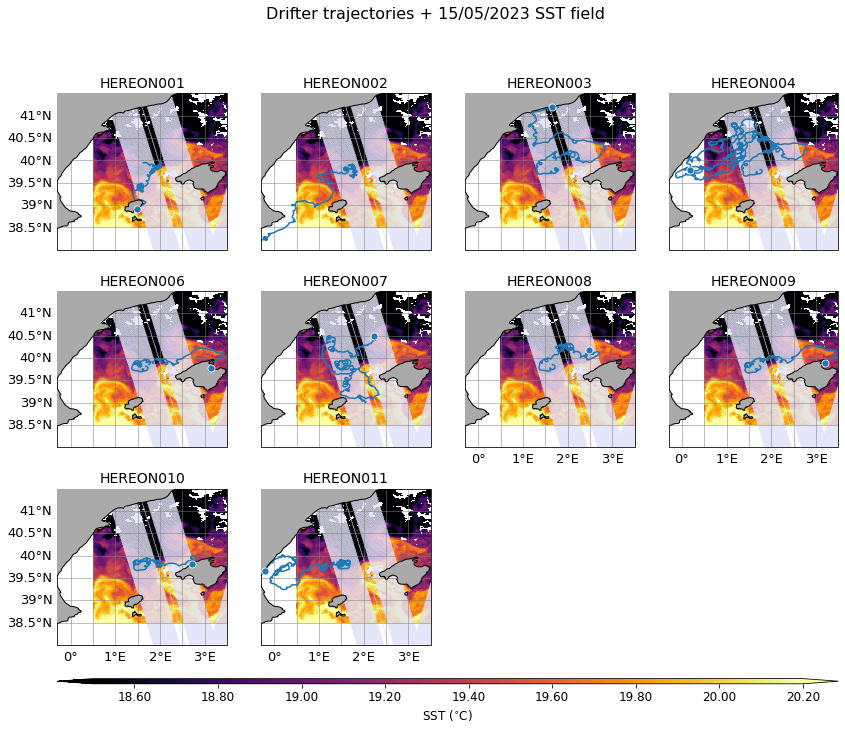

In [73]:
aa = 0 # axes index

plt.close()
plt.cla
plt.clf

gs_x = 4
gs_y = 4

############
fig = plt.figure(figsize=(14,11))

gs  = gridspec.GridSpec(gs_x, gs_y, height_ratios=[.33, .33, .33, .01])
axC = plt.subplot(gs[-1,:])

######
# Leg1 

# fig, ax = plt.subplots(2, 3, sharex = 'col', sharey = 'row', figsize = (9, 6))
# fig.tight_layout(pad =3.0)

for ii, ds in enumerate(ds_her_leg1):
    ax1  = plt.subplot(gs[aa], projection=ccrs.PlateCarree())
    cs = FaSt_SWOT_features(ax1, aa, ds, gs_x, gs_y, field=True, sub_uneq=2, map_extent=[-.3, 3.5, 38., 41.5])

    #     ds_d07 = ds.sel(time=np.logical_and(ds.time.dt.day > last_day-1, ds.time.dt.day < last_day+1))
    #     ds_m05d07 = ds_d07.sel(time=np.logical_and(ds_d07.time.dt.month > 4, ds_d07.time.dt.month < 6))

    #     if ds_m05d07.time.shape[0] == 0 :
    #         print('No drifter data: ' + svp_leg1_n[ii] + ' ' + str(ds_m05d07.attrs['instrument_serial']))
    #         continue
    #     else:
    ax1.plot(ds.LON, ds.LAT, transform=ccrs.PlateCarree(), c='C0') 
    ax1.scatter(ds.LON[-1], ds.LAT[-1], s=50, c='C0', edgecolor='w', linewidths=0.8,
                zorder=500, transform=ccrs.PlateCarree())
        
    aa+=1
    
######

cbar = plt.colorbar(cs,
            cax=axC,
            orientation='horizontal',
            extend='both',
            #shrink=0.6,
            #     ticks=np.linspace(vmin,vmax,6),
            format='%3.2f'
            )
cbar_label = r'SST ($^{\circ}$C)'
cbar.ax.tick_params(labelsize=12)
cbar.ax.set_xlabel(cbar_label, fontsize=12)

# plt.tight_layout()
plt.suptitle('Drifter trajectories + 15/05/2023 SST field', size=16);

# plt.savefig('HEREON_drifters_150523_SST_150523.png', dpi=300)


<a id="2.3.3."></a> <br>
### 2.3.3. Full trajectories (traj. extent):


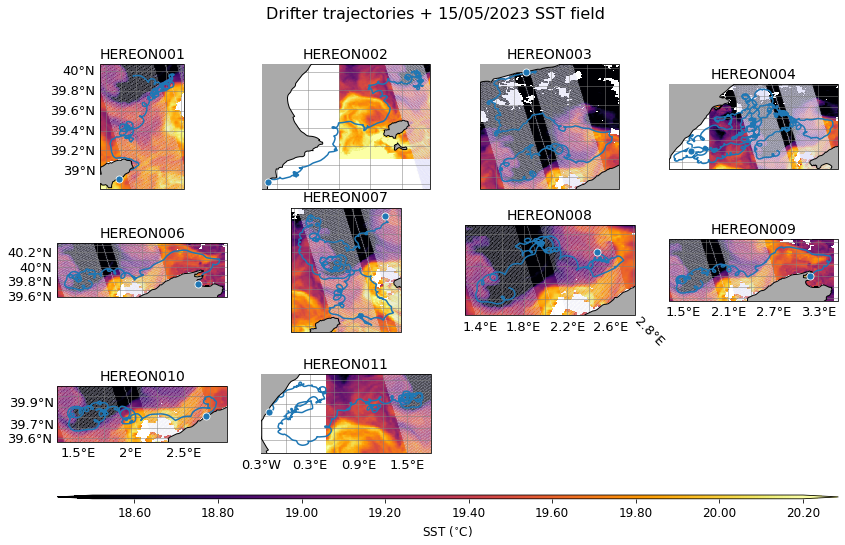

In [74]:
aa = 0 # axes index

plt.close()
plt.cla
plt.clf

gs_x = 4
gs_y = 4

############
fig = plt.figure(figsize=(14, 8))

gs  = gridspec.GridSpec(gs_x, gs_y, height_ratios=[.33, .33, .33, .01])
axC = plt.subplot(gs[-1,:])


######
# Leg1 

# fig, ax = plt.subplots(2, 3, sharex = 'col', sharey = 'row', figsize = (9, 6))
# fig.tight_layout(pad =3.0)

## SVP-B:
for ii, ds in enumerate(ds_her_leg1):
    ax1  = plt.subplot(gs[aa], projection=ccrs.PlateCarree())
    map_es = [ds.LON.min().values -.1, ds.LON.max().values +.1, 
              ds.LAT.min().values -.1, ds.LAT.max().values +.1]
    cs = FaSt_SWOT_features(ax1, aa, ds, gs_x, gs_y, field=True, map_extent=map_es, sub_uneq=2)

    #     ds_d07 = ds.sel(time=np.logical_and(ds.time.dt.day > last_day-1, ds.time.dt.day < last_day+1))
    #     ds_m05d07 = ds_d07.sel(time=np.logical_and(ds_d07.time.dt.month > 4, ds_d07.time.dt.month < 6))

    #     if ds_m05d07.time.shape[0] == 0 :
    #         print('No drifter data: ' + svp_leg1_n[ii] + ' ' + str(ds_m05d07.attrs['instrument_serial']))
    #         continue
    #     else:
    ax1.plot(ds.LON, ds.LAT, transform=ccrs.PlateCarree(), c='C0') 
    ax1.scatter(ds.LON[-1], ds.LAT[-1], s=50, c='C0', edgecolor='w', linewidths=0.8,
                zorder=500, transform=ccrs.PlateCarree())
        
    aa+=1
######

cbar = plt.colorbar(cs,
            cax=axC,
            orientation='horizontal',
            extend='both',
            #shrink=0.6,
            #     ticks=np.linspace(vmin,vmax,6),
            format='%3.2f'
            )
cbar_label = r'SST ($^{\circ}$C)'
cbar.ax.tick_params(labelsize=12)
cbar.ax.set_xlabel(cbar_label, fontsize=12)

# plt.tight_layout()
plt.suptitle('Drifter trajectories + 15/05/2023 SST field', size=16);

# plt.savefig('CARTHE1_drifters_150523_15h_SST_150523.png', dpi=300)

<a id="2.3.4."></a> <br>
### 2.3.4.  Only trajectory on day 15/05/23 (+/- 1 day):

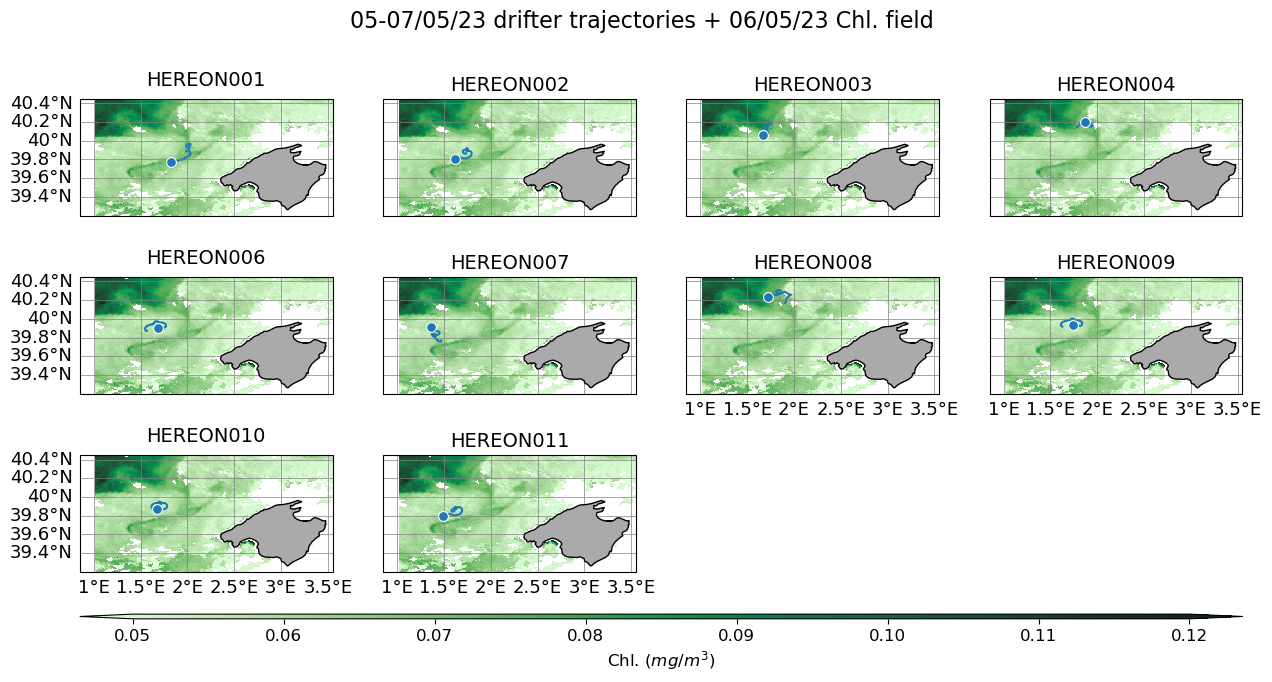

In [55]:
dd1 = '05'
dd2 = '07'

aa = 0 # axes index

plt.close()
plt.cla
plt.clf

gs_x = 4
gs_y = 4

############
fig = plt.figure(figsize=(15, 7))

gs  = gridspec.GridSpec(gs_x, gs_y, height_ratios=[.33, .33, .33, .01])
axC = plt.subplot(gs[-1,:])


######
for ii, ds in enumerate(ds_her_leg1):
    ax1  = plt.subplot(gs[aa], projection=ccrs.PlateCarree())
    map_es = [ds.LON.min().values -.1, ds.LON.max().values +.1, 
              ds.LAT.min().values -.1, ds.LAT.max().values +.1]
    
    cs = FaSt_SWOT_features(ax1, aa, gs_x, gs_y, ds_sat, field='Chl', map_extent=[.85, 3.55, 39.2, 40.45], sub_uneq=2, SWOT_swath=False)
    
    ds_s = ds.sel(time=slice("2023-05-"+dd1, "2023-05-"+dd2))
    if ds_s.time.size == 0:
        print('No trajectory segment on these days')
        #continue
    else:
        ax1.plot(ds_s.LON, ds_s.LAT, transform=ccrs.PlateCarree(), c='C0') 
        ax1.scatter(ds_s.LON[-1], ds_s.LAT[-1], s=50, c='C0', edgecolor='w', linewidths=0.8,
               zorder=500, transform=ccrs.PlateCarree())

    aa+=1
######

cbar = plt.colorbar(cs,
            cax=axC,
            orientation='horizontal',
            extend='both',
            #shrink=0.6,
            #     ticks=np.linspace(vmin,vmax,6),
            format='%3.2f'
            )
cbar_label = r'Chl. ($mg/m^3$)'
cbar.ax.tick_params(labelsize=12)
cbar.ax.set_xlabel(cbar_label, fontsize=12)

# plt.tight_layout()
plt.suptitle(dd1 + '-' + dd2 + '/05/23 drifter trajectories + 06/05/23 Chl. field', size=16);

# plt.savefig('CARTHE1_drifters_150523_15h_SST_150523.png', dpi=300)

### Individual plots:

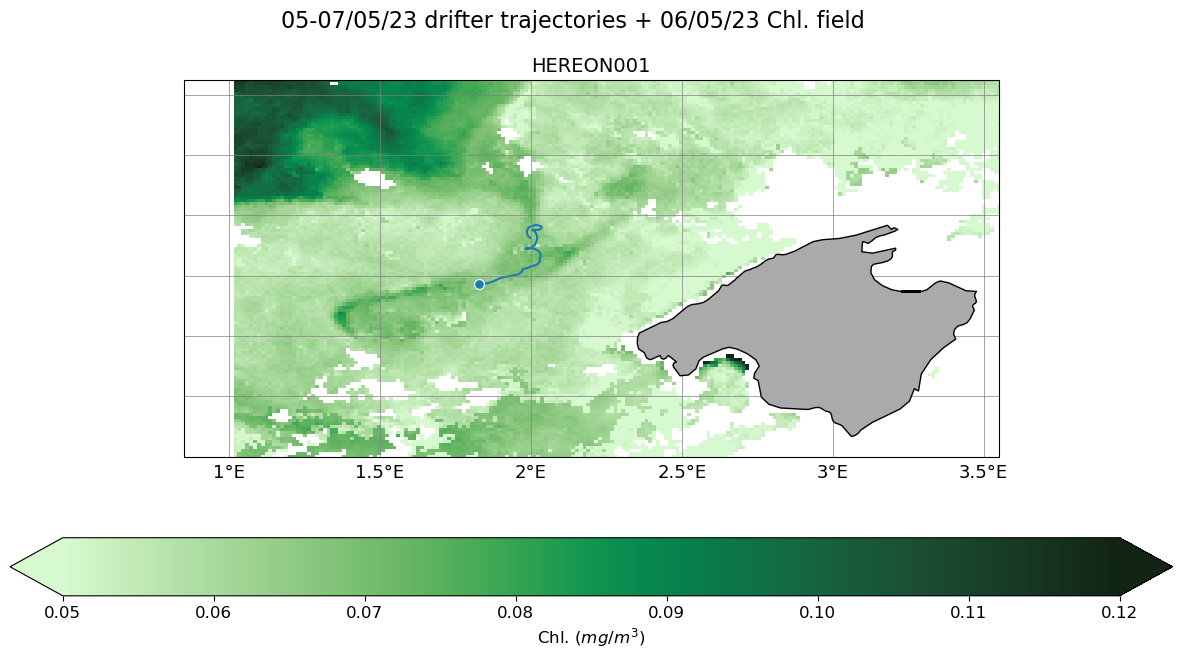

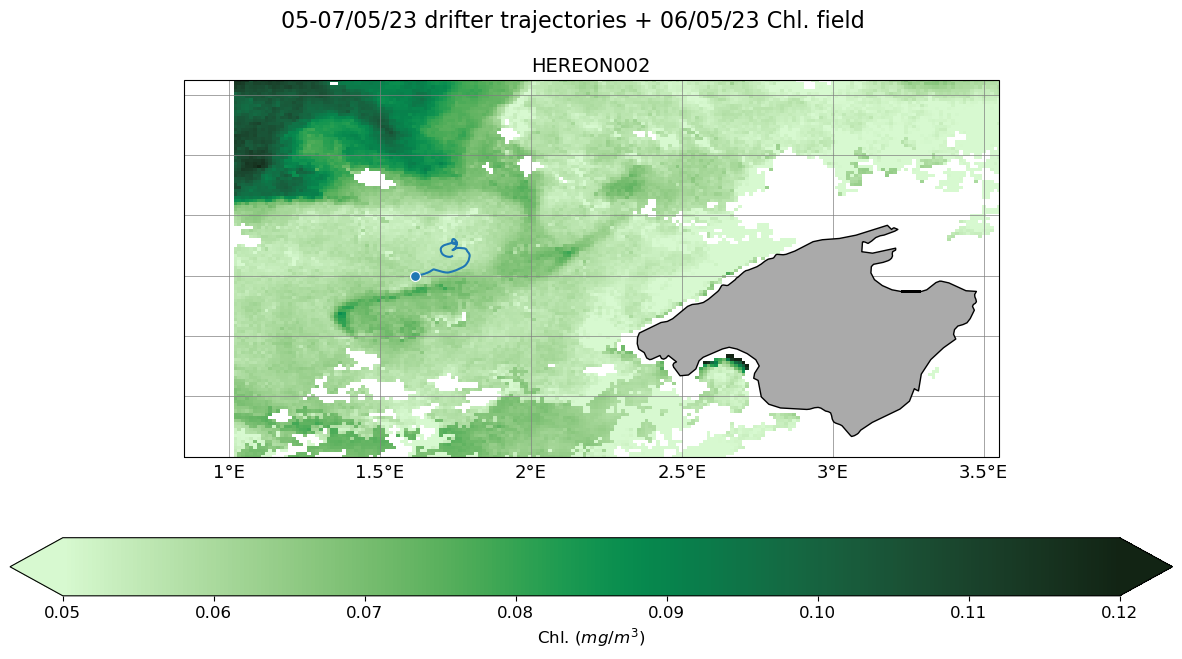

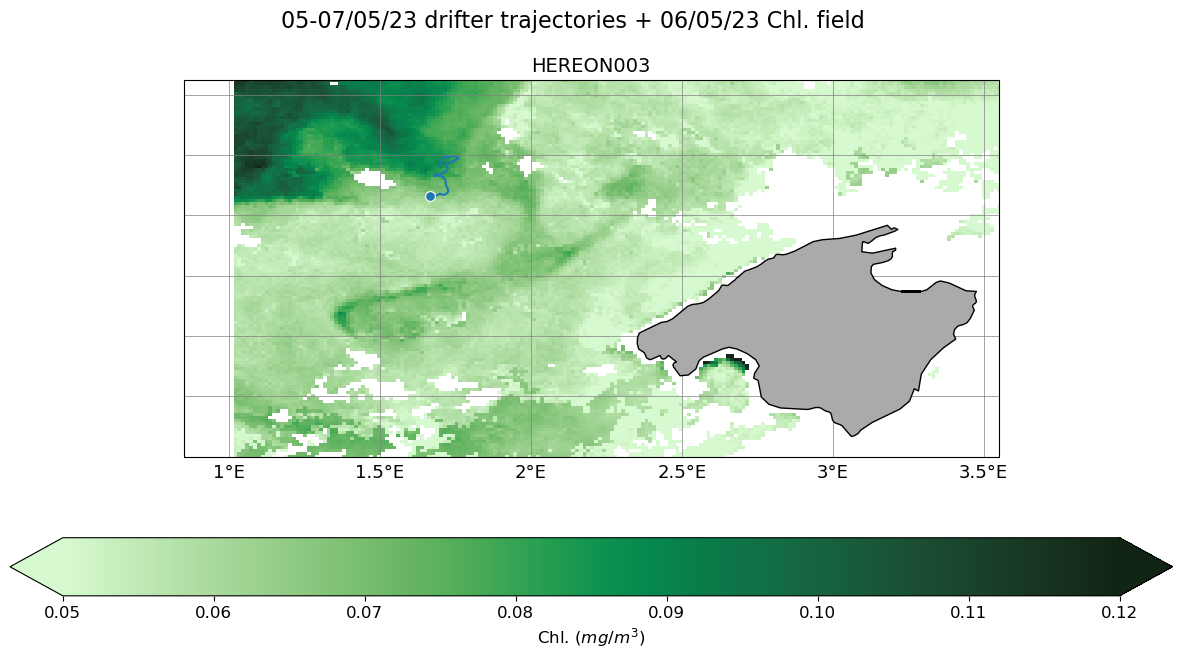

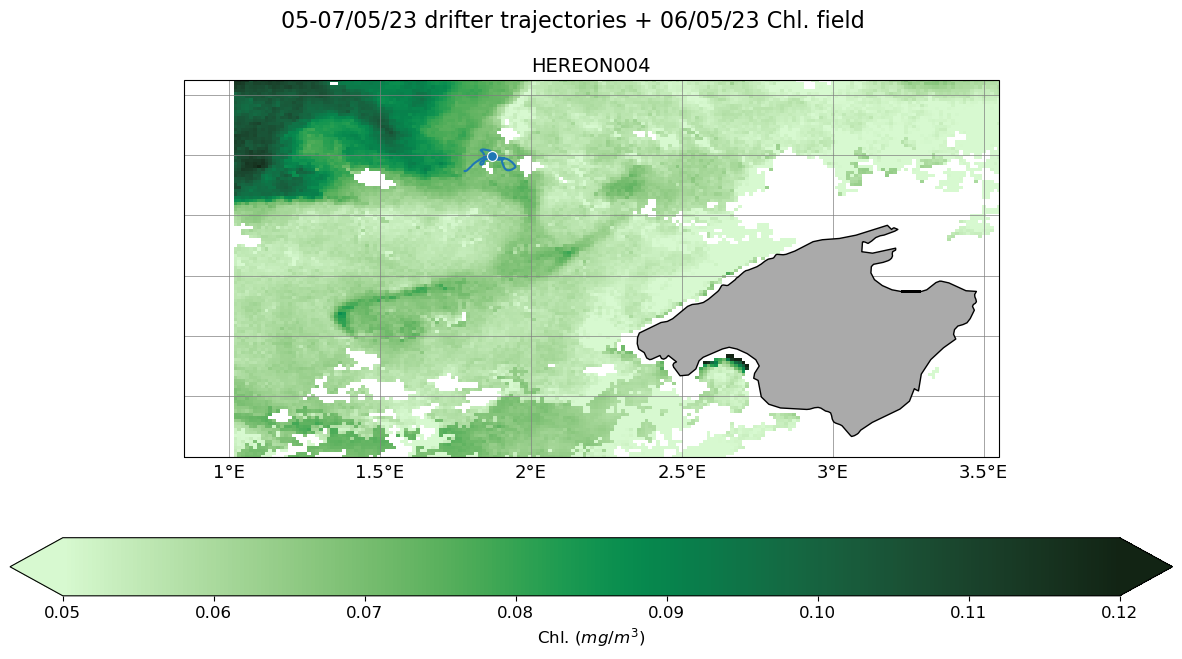

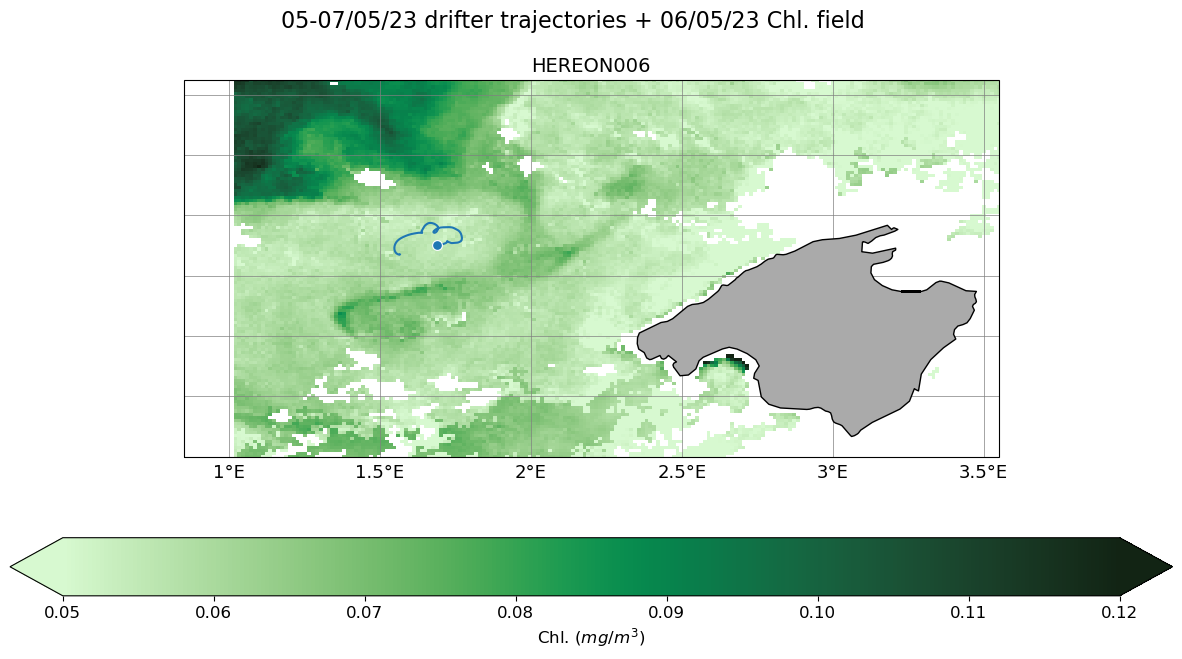

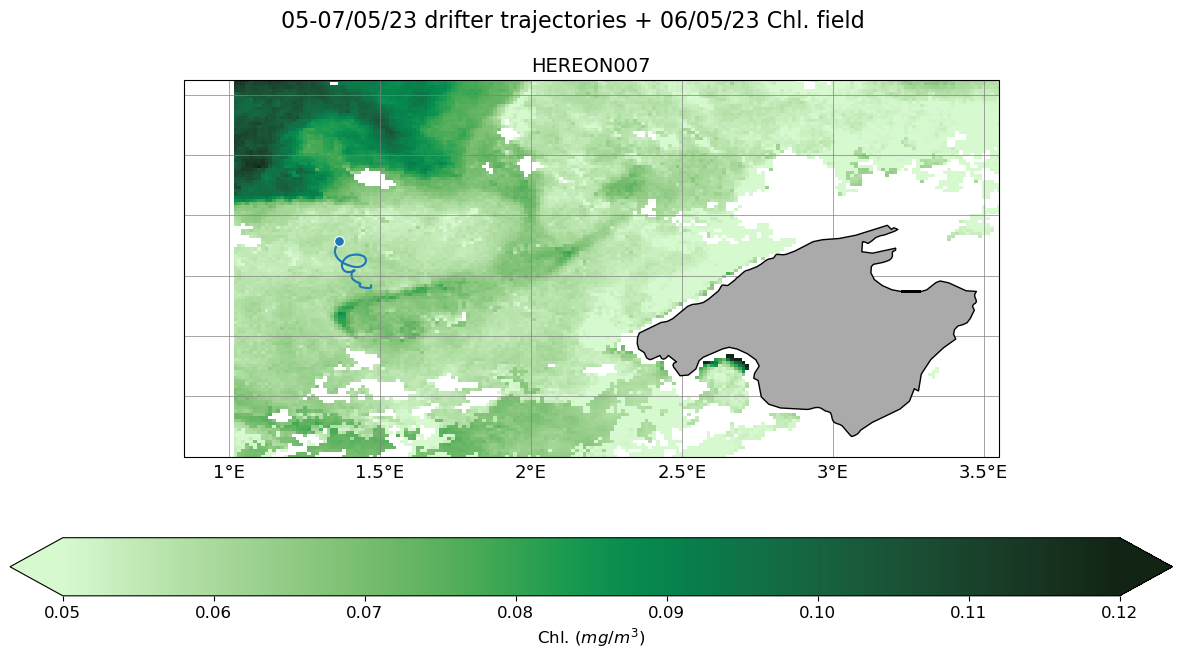

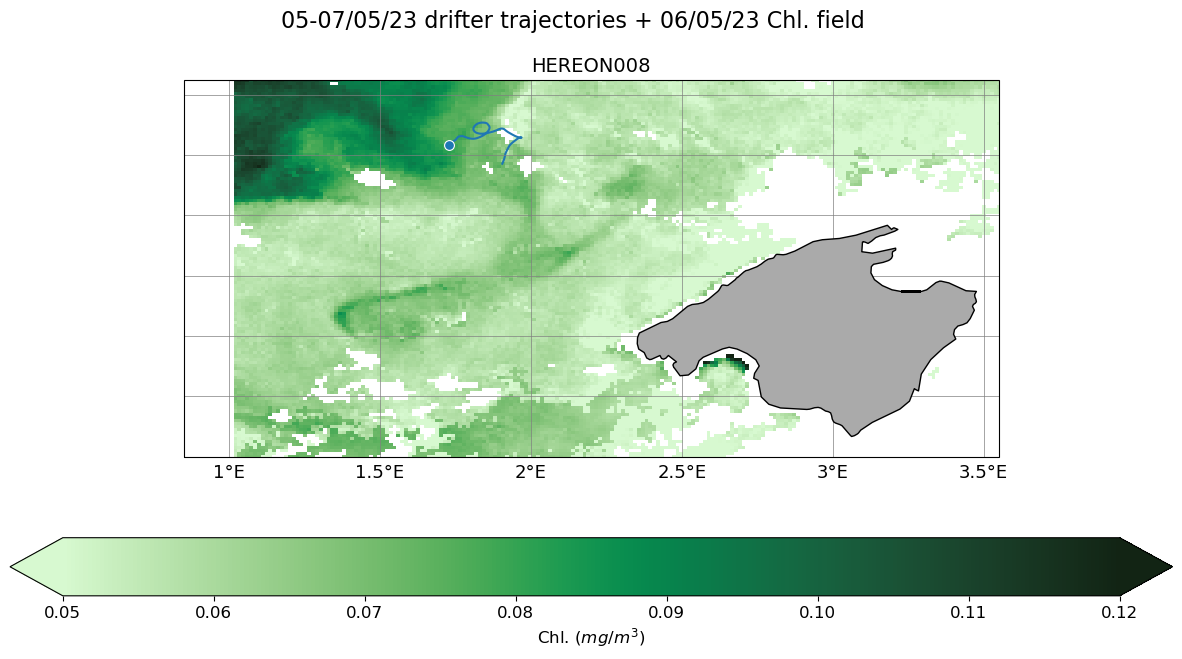

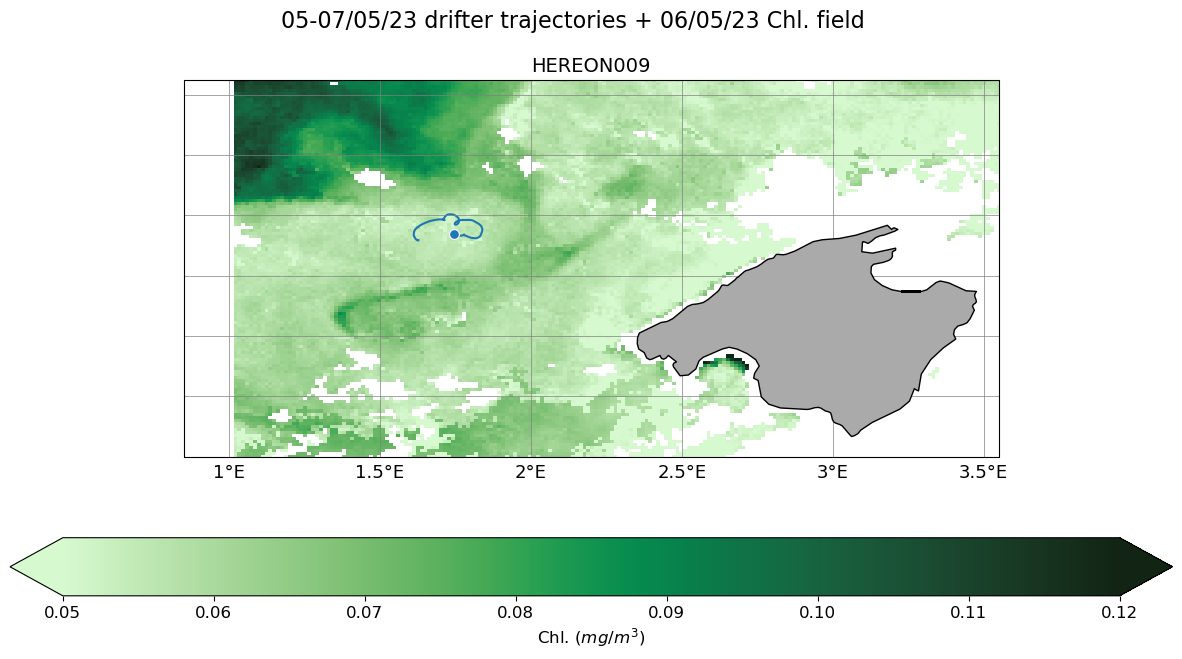

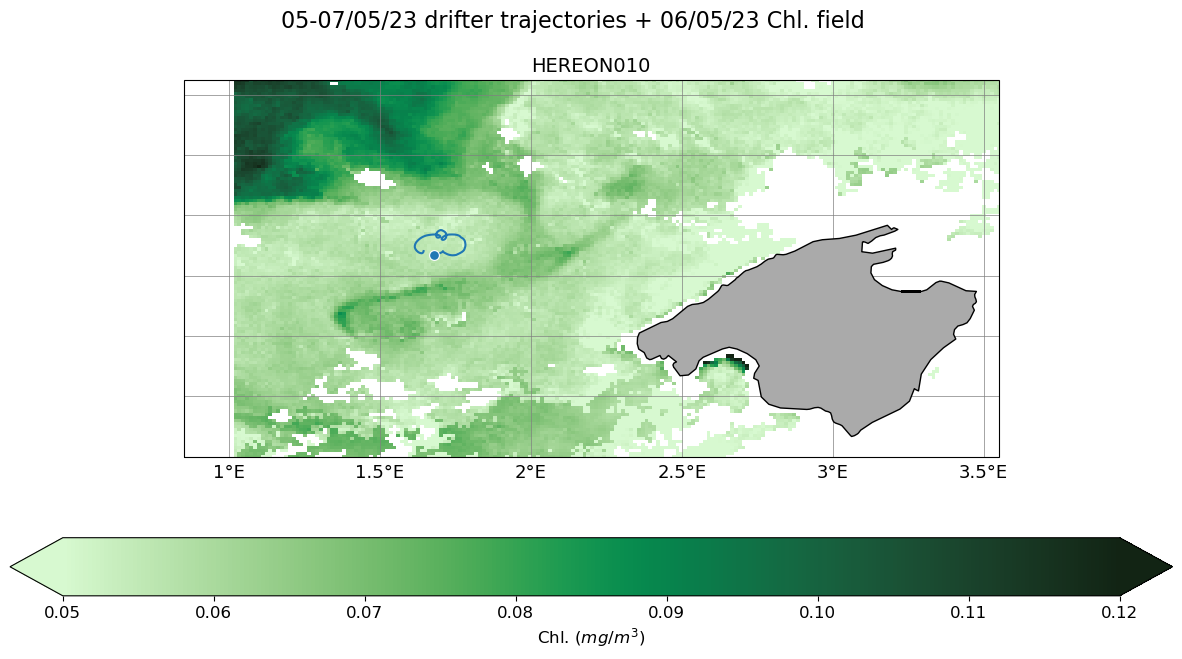

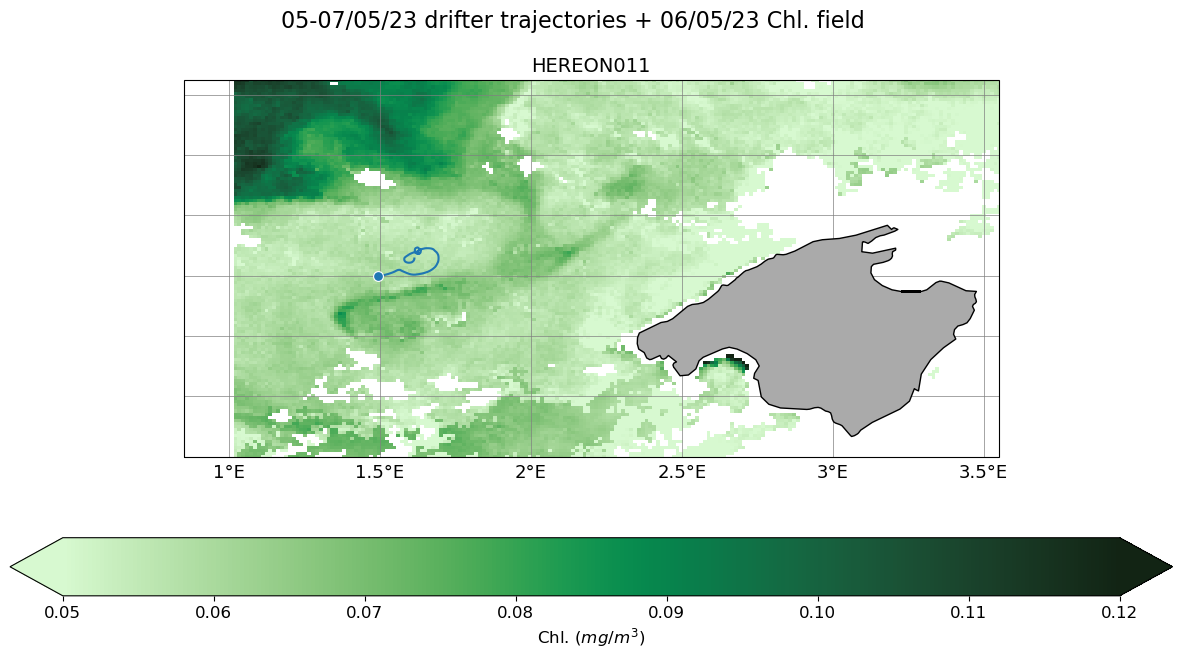

In [56]:
dd1 = '05'
dd2 = '07'

######
for ii, ds in enumerate(ds_her_leg1):
    plt.close()
    plt.cla
    plt.clf

    ############
    fig = plt.figure(figsize=(15, 7))

    ax1  = plt.subplot(111, projection=ccrs.PlateCarree())
    map_es = [ds.LON.min().values -.1, ds.LON.max().values +.1, 
              ds.LAT.min().values -.1, ds.LAT.max().values +.1]
    
    cs = FaSt_SWOT_features(ax1, aa, gs_x, gs_y, ds_sat, field='Chl', map_extent=[.85, 3.55, 39.2, 40.45], sub_uneq=2, SWOT_swath=False)
    
    ds_s = ds.sel(time=slice("2023-05-"+dd1, "2023-05-"+dd2))
    if ds_s.time.size == 0:
        print('No trajectory segment on these days')
        #continue
    else:
        ax1.plot(ds_s.LON, ds_s.LAT, transform=ccrs.PlateCarree(), c='C0') 
        ax1.scatter(ds_s.LON[-1], ds_s.LAT[-1], s=50, c='C0', edgecolor='w', linewidths=0.8,
               zorder=500, transform=ccrs.PlateCarree())

    aa+=1
######

    cbar = plt.colorbar(cs,
                #cax=axC,
                orientation='horizontal',
                extend='both',
                #shrink=0.6,
                #     ticks=np.linspace(vmin,vmax,6),
                format='%3.2f'
                )
    cbar_label = r'Chl. ($mg/m^3$)'
    cbar.ax.tick_params(labelsize=12)
    cbar.ax.set_xlabel(cbar_label, fontsize=12)

    # plt.tight_layout()
    plt.suptitle(dd1 + '-' + dd2 + '/05/23 drifter trajectories + 06/05/23 Chl. field', size=16);

    # plt.savefig('CARTHE1_drifters_150523_15h_SST_150523.png', dpi=300)
    plt.show()

<a id="2.3.5."></a> <br>
### 2.3.5.  Full trajectories (regional zoom) + Highlight of trajectory on day 15/05/23 (+/- 1 day):

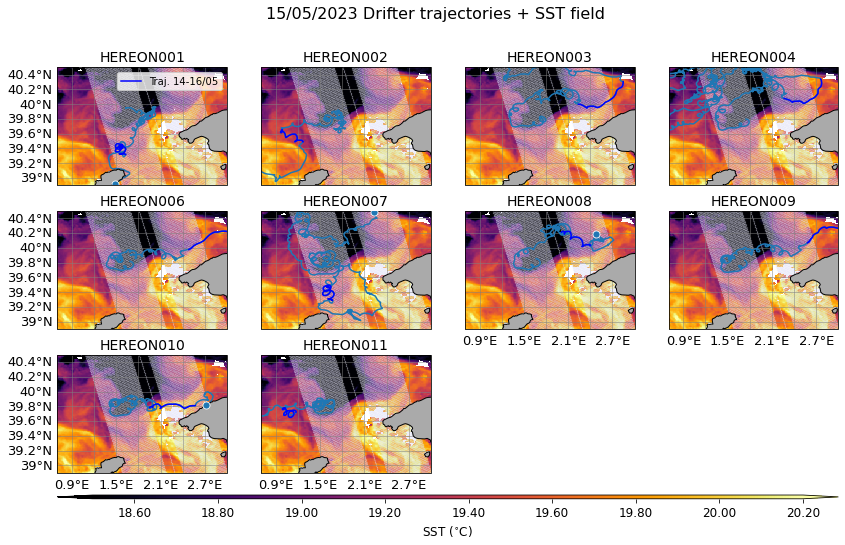

In [119]:
aa = 0 # axes index

plt.close()
plt.cla
plt.clf

gs_x = 4
gs_y = 4

############
fig = plt.figure(figsize=(14, 8))

gs  = gridspec.GridSpec(gs_x, gs_y, height_ratios=[.33, .33, .33, .01])
axC = plt.subplot(gs[-1,:])


######
# Leg1 

# fig, ax = plt.subplots(2, 3, sharex = 'col', sharey = 'row', figsize = (9, 6))
# fig.tight_layout(pad =3.0)

## SVP-B:
for ii, ds in enumerate(ds_her_leg1):
    ax1  = plt.subplot(gs[aa], projection=ccrs.PlateCarree())
    map_es = [ds.LON.min().values -.1, ds.LON.max().values +.1, 
              ds.LAT.min().values -.1, ds.LAT.max().values +.1]
    
    cs = FaSt_SWOT_features(ax1, aa, ds_s, gs_x, gs_y, field=True, sub_uneq=2) #,map_extent=[0.1, 3.5, 38.7, 40.9]

    ax1.plot(ds.LON, ds.LAT, transform=ccrs.PlateCarree(), c='C0') 
    ax1.scatter(ds.LON[-1], ds.LAT[-1], s=50, c='C0', edgecolor='w', linewidths=0.8,
               zorder=500, transform=ccrs.PlateCarree())
    
    ds_s = ds.sel(time=slice("2023-05-14", "2023-05-16"))
    if ds_s.time.size == 0:
        print('No trajectory segment on these days')
        #continue
    else:
        ax1.plot(ds_s.LON, ds_s.LAT, transform=ccrs.PlateCarree(), c='b', label='Traj. 14-16/05') 
        if aa==0:
            ax1.legend(loc=1)
    
    aa+=1
######

cbar = plt.colorbar(cs,
            cax=axC,
            orientation='horizontal',
            extend='both',
            #shrink=0.6,
            #     ticks=np.linspace(vmin,vmax,6),
            format='%3.2f'
            )
cbar_label = r'SST ($^{\circ}$C)'
cbar.ax.tick_params(labelsize=12)
cbar.ax.set_xlabel(cbar_label, fontsize=12)

# plt.tight_layout()
plt.suptitle('15/05/2023 Drifter trajectories + SST field', size=16);

# plt.savefig('CARTHE1_drifters_150523_15h_SST_150523.png', dpi=300)

<a id="2.3.6."></a> <br>
### 2.3.6. Extra
### 15 days from deployment (would need to choose another day for SST image):

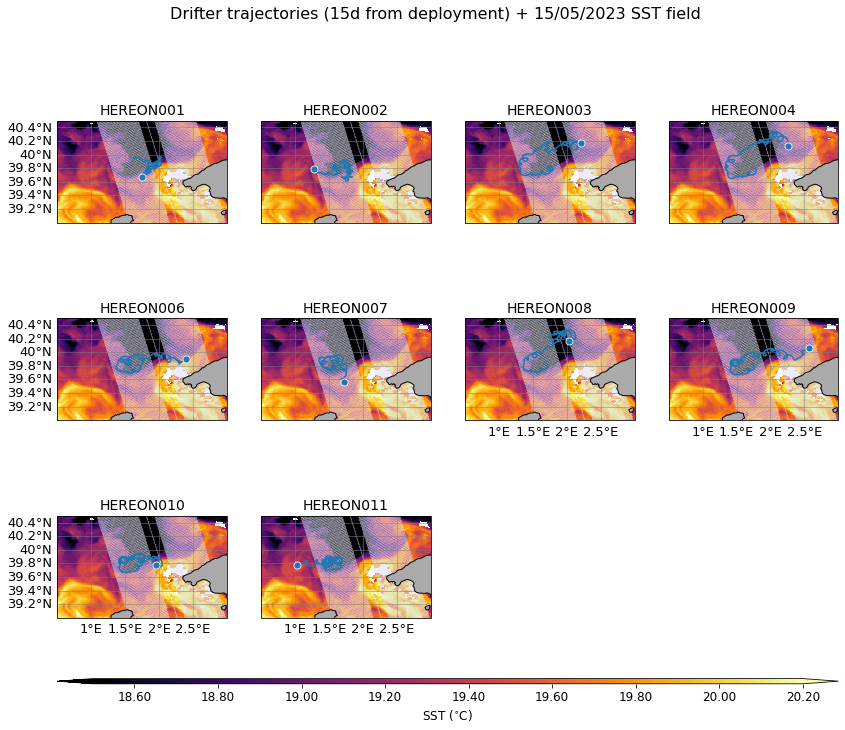

In [121]:
dd2 = '15'

aa = 0 # axes index

plt.close()
plt.cla
plt.clf

gs_x = 4
gs_y = 4

############
fig = plt.figure(figsize=(14,11))

gs  = gridspec.GridSpec(gs_x, gs_y, height_ratios=[.33, .33, .33, .01])
axC = plt.subplot(gs[-1,:])

######
# Leg1 

# fig, ax = plt.subplots(2, 3, sharex = 'col', sharey = 'row', figsize = (9, 6))
# fig.tight_layout(pad =3.0)

for ii, ds in enumerate(ds_her_leg1):
    ax1  = plt.subplot(gs[aa], projection=ccrs.PlateCarree())
    cs = FaSt_SWOT_features(ax1, aa, ds, gs_x, gs_y, field=True, sub_uneq=2, map_extent=[0.5, 3., 39., 40.5])
    
    dd1 = str(ds.time.dt.day.values[0]).zfill(2)
    mm1 = str(ds.time.dt.month.values[0]).zfill(2)    
    dm2 = ds.time.values[0] + np.timedelta64(15, 'D')
    date2 = str(dm2).split('T')[0]
    ds_last = ds.sel(time=slice('2023-' + mm1 + '-' + dd1 + 'T00:00:00', date2 + 'T23:59:59'))
    if ds_last.time.shape[0] == 0 :
        #print('No drifter data')
        continue
    else:
        ax1.plot(ds_last.LON, ds_last.LAT, transform=ccrs.PlateCarree(), c='C0') 
        ax1.scatter(ds_last.LON[-1], ds_last.LAT[-1], s=50, c='C0', edgecolor='w', linewidths=0.8,
                zorder=500, transform=ccrs.PlateCarree())
        
    aa+=1
    
######

cbar = plt.colorbar(cs,
            cax=axC,
            orientation='horizontal',
            extend='both',
            #shrink=0.6,
            #     ticks=np.linspace(vmin,vmax,6),
            format='%3.2f'
            )
cbar_label = r'SST ($^{\circ}$C)'
cbar.ax.tick_params(labelsize=12)
cbar.ax.set_xlabel(cbar_label, fontsize=12)

# plt.tight_layout()
plt.suptitle('Drifter trajectories (15d from deployment) + 15/05/2023 SST field', size=16);

# plt.savefig('HEREON_drifters_150523_SST_150523.png', dpi=300)
